<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Physics Analysis 1 — Solar Neutrino Day-Night Asymmetry
---

This notebook computes the **day-night asymmetry** $A_{\rm DN}$ of the solar electron-neutrino survival probability at a surface detector. During the night, solar neutrinos traverse a chord of the Earth before reaching the detector; the Earth's electron density partially re-establishes coherent MSW mixing, modifying the survival probability relative to the daytime value. This **Earth matter regeneration** is the physical origin of $A_{\rm DN}$.

The notebook builds the full chain from solar exit mass-basis weights to exposure-averaged asymmetry and discusses sensitivity to oscillation parameters.

---

## Table of Contents

| § | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background**: solar exit state, day/night probabilities, asymmetry definition, regeneration factor |
| [1](#1.-Libraries) | Libraries |
| [2](#2.-Paths-and-Configuration) | Paths and Configuration |
| [3](#3.-Preliminary-Calculations) | **Preliminary Calculations**: 3.1 daytime $P_{ee}^{\rm day}$ (eta-independence), 3.2 nighttime $P_{ee}^{\rm night}(E,\eta)$, 3.3 heatmap |
| [4](#4.-Day-Night-Spectral-Comparison) | **Day-Night Spectral Comparison**: spectra overlay, spectral difference, regeneration factor |
| [5](#5.-Day-Night-Asymmetry-vs-Energy-and-Nadir) | **Day-Night Asymmetry $A_{\rm DN}$**: 5.1 vs energy, 5.2 vs nadir angle, 5.3 heatmap |
| [6](#6.-Exposure-Averaged-Asymmetry) | **Exposure-Averaged Asymmetry**: 6.1 per-detector spectra, 6.2 integrated $A_{\rm DN}^{\rm int}$ |
| [7](#7.-Detected-Level-Observable) | **Detected Level Observable**: 7.1 effective cross section $\sigma_{\rm eff}$, 7.2 rate spectra and $A_{\rm DN}$ vs threshold, 7.3 comparison with measurements |
| [8](#8.-Sensitivity-to-Parameters) | **Sensitivity to Oscillation Parameters**: $\theta_{12}$, $\Delta m^2_{21}$ scans |
| [9](#9.-Summary) | Summary |

## 0. Theory Background

### 0.1 Solar Exit State — Incoherent Mass-Basis Weights

Electron neutrinos produced in the solar interior undergo adiabatic MSW propagation through the solar density gradient (see *SolarNeutrino2 — MSW Resonance*). By the time they exit the sun, quantum decoherence over the $\sim$1 AU vacuum propagation destroys all off-diagonal mass-eigenstate coherence *(Stodolsky 1975)*. The resulting state is an **incoherent mixture of mass eigenstates** with weights

$$w_i(E) = T_{ei}(E) \equiv \left|\langle \nu_i | \nu_e^{\rm solar}(E)\rangle\right|^2$$

where $T_{ei}$ is the adiabatic transition amplitude computed in `medium.solar.matter_mixing`. These weights depend only on energy $E$ and the solar density profile — not on the detector geometry.

### 0.2 Daytime Survival Probability

During the **day** ($\eta > 90°$, neutrinos arriving from above the horizon), the mass eigenstates propagate from the Sun to the detector in vacuum. The electron-flavour survival probability is the incoherent projection onto the vacuum PMNS matrix *(Haxton 1986, Parke 1986)*:

$$P_{ee}^{\rm day}(E) = \sum_{i=1}^{3} |U_{ei}|^2\, w_i(E)$$

This quantity is **independent of the nadir angle** $\eta$: it depends only on the oscillation parameters and the solar production profile, not on the Earth geometry.
In the LMA regime at high energy, $w_2 \to 1$ and $P_{ee}^{\rm day} \to |U_{e2}|^2 \approx 0.30$.

### 0.3 Nighttime Probability — Earth Matter Regeneration

During the **night** ($\eta < 90°$), neutrinos cross a chord of the Earth of length

$$L(\eta) = 2\,R_\oplus\cos\eta$$

The Earth's electron density introduces a matter potential $V_e = \sqrt{2}\,G_F\,n_e(r)$ along the path, partially re-establishing coherent flavour mixing. The final probability at the detector is *(Mikheyev & Smirnov 1986, Bouchez et al. 1986)*:

$$P_{ee}^{\rm night}(E,\eta) = \sum_{i,j=1}^{3} |U_{\rm Earth,\,ei}|^2\, w_j(E)$$

where $U_{\rm Earth}$ is the Earth evolution operator built analytically from the PREM electron-density profile (`medium.earth.probability.earth_probability_state_analytical`, with `massbasis=True` to accept incoherent weights $w_i$ as input).

### 0.4 Day-Night Asymmetry and Regeneration Factor

The experimentally observable **day-night asymmetry** is defined as

$$A_{\rm DN}(E,\eta) \;=\; \frac{2\bigl(P_{ee}^{\rm day}(E) - P_{ee}^{\rm night}(E,\eta)\bigr)}{P_{ee}^{\rm day}(E) + P_{ee}^{\rm night}(E,\eta)}$$

Positive $A_{\rm DN}$ means the daytime rate exceeds the nighttime rate (matter suppression); negative $A_{\rm DN}$ means Earth regeneration increases the night rate. In the LMA regime above a few MeV, $P_{ee}^{\rm night} > P_{ee}^{\rm day}$ so $A_{\rm DN} < 0$ *(Lisi & Montanino 1997)*.

The **regeneration factor** quantifies the Earth effect relative to the vacuum mixing scale:

$$f_{\rm reg}(E,\eta) = \frac{P_{ee}^{\rm night}(E,\eta) - P_{ee}^{\rm day}(E)}{2\sin^2\theta_{12}}$$

### 0.5 Exposure-Averaged Asymmetry and Experimental Status

A real detector averages over the nadir-angle distribution of night exposure $W_{\rm night}(\eta)$ (derived in *Earth4 — Exposure Analysis*):

$$\langle P_{ee}^{\rm night}\rangle(E) = \int_0^{\pi/2} W_{\rm night}(\eta)\,P_{ee}^{\rm night}(E,\eta)\,d\eta$$

The measured $A_{\rm DN}$ involves this exposure-averaged quantity. LMA predicts $|A_{\rm DN}| \lesssim 3\%$ at $E \sim 10$ MeV, consistent with Super-K measurements *(Abe et al. 2016)*:

| Experiment | $\langle A_{\rm DN}\rangle$ | Notes |
|------------|-------------------------------|-------|
| Super-K IV | $(-3.2 \pm 1.1_{\rm stat} \pm 0.5_{\rm syst})\%$ | $^8$B, $E_{\rm thr}=3.5$ MeV, SK-IV |
| SNO (NCD)  | $(7 \pm 49_{\rm stat})\%$ | $^8$B NC+CC |
| Borexino   | $(-0.02 \pm 0.67)\%$ | $^8$B (low stat) |

### References

- L. Wolfenstein, *Neutrino oscillations in matter*, Phys. Rev. D **17**, 2369 (1978)
- S.P. Mikheyev & A.Yu. Smirnov, *Resonance enhancement of oscillations in matter*, Sov. J. Nucl. Phys. **42**, 913 (1985)
- S.P. Mikheyev & A.Yu. Smirnov, *Resonant amplification of neutrino oscillations in matter*, Nuovo Cim. C **9**, 17 (1986)
- J. Bouchez et al., *Matter effects for solar neutrino oscillations*, Z. Phys. C **32**, 499 (1986)
- W.C. Haxton, *Adiabatic conversion of solar neutrinos*, Phys. Rev. Lett. **57**, 1271 (1986)
- S.J. Parke, *Nonadiabatic level crossing in resonant neutrino oscillations*, Phys. Rev. Lett. **57**, 1275 (1986)
- E. Lisi & D. Montanino, *Earth regeneration effect in solar-neutrino oscillations*, Phys. Rev. D **56**, 1792 (1997)
- N. Vinyoles et al. (B16 AGSS09), *A new Generation of Standard Solar Models*, Astrophys. J. **835**, 202 (2017)
- I. Esteban et al. (NuFIT 5.2), *The fate of hints: updated global analysis of three-flavor neutrino oscillations*, JHEP **09**, 178 (2020)
- K. Abe et al. (Super-K), *Solar neutrino measurements in Super-Kamiokande-IV*, Phys. Rev. D **94**, 052010 (2016)
- B. Aharmim et al. (SNO), *Combined analysis of all three phases of solar neutrino data from the Sudbury Neutrino Observatory*, Phys. Rev. C **88**, 025501 (2013)

## 1. Libraries

In [1]:
from __future__ import annotations

import math
import dataclasses

import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt

from tpeanuts.util.context import RuntimeContext
from tpeanuts.util.type import to_numpy
import tpeanuts.util.constant as constant
from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.medium.solar.profile import SolarProfile
from tpeanuts.medium.solar.probability import solar_probability_state, solar_probability_mass
from tpeanuts.medium.earth.profile import EarthParameters, EarthProfile
from tpeanuts.medium.earth.probability import earth_probability_state_analytical
from tpeanuts.medium.earth.exposure_table import ExposureParameters, build_nadir_exposure
from tpeanuts.medium.earth.exposure_integration import earth_probability_exposure
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show
from tpeanuts.util.math import numpy_trapezoid


## 2. Paths and Configuration

### 2.1 Paths

`load_notebook_config()` resolves the repository root, applies the shared matplotlib/torch/numpy style, and creates the output directory. All figures from this notebook are saved under `analysis/earth/`.

In [2]:
config     = load_notebook_config()
ctx        = RuntimeContext.resolve(config.device, config.dtype)
OUTPUT_DIR = config.output_dir("analysis", "earth")
EARTH_DENSITY_CSV = config.earth_density_file

print(f'Package dir : {config.package_dir}')
print(f'Output dir  : {OUTPUT_DIR}')
print(f'Device      : {ctx.device}   dtype: {ctx.dtype}')

Package dir : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Output dir  : v:\output\analysis\earth
Device      : cpu   dtype: torch.float64


### 2.2 Configuration

All plots use NuFIT 5.2 Normal Ordering as the physical benchmark. The analysis focuses on the $^8$B source (the dominant high-energy solar component) over the energy range 1–16 MeV, where the MSW resonance and Earth regeneration effects are most prominent. Four detectors spanning a range of geographic latitudes are compared throughout.

| Parameter | Value | Description |
|-----------|-------|-------------|
| Oscillation preset | `_SM_NUFIT52_NO` | NuFIT 5.2, Normal Ordering |
| $\Delta m^2_{21}$ | $7.41\times10^{-5}$ eV² | Solar mass splitting |
| $\theta_{12}$ | $33.41°$ | Solar mixing angle |
| $\theta_{13}$ | $8.57°$ | Reactor mixing angle |
| Solar source | $^8$B | Dominant high-energy solar source |
| Solar profile | B16 AGSS09 | Zenodo SF3, $r\in[0,1]\,R_\odot$ |
| Earth profile | even-power (PREM) | `profile_perturbative_name="even_power"` |
| Detector depth | 2000 m | Typical underground laboratory depth |
| Energy range | 1–16 MeV | $^8$B relevant range |
| Nadir grid | 0.6°–89.8° | Night side, 90 points |

| Detector | Latitude | Reference |
|----------|----------|-----------|
| Super-Kamiokande | +36.4°N | Abe et al. (2016) |
| Borexino | +42.5°N | Agostini et al. (2018) |
| SNO+ | +46.5°N | Anderson et al. (2021) |
| JUNO | +22.1°N | Abusleme et al. (2022) |

In [3]:
oscillation   = PropagationConfig.oscillation_parameters_from_preset("_SM_NUFIT52_NO", context=ctx)
solar_profile = SolarProfile.default(context=ctx)

R_E_KM        = constant.R_E_KM
EARTH_DEPTH_M = 2000.0
ICB_KM        = 1221.5   # inner-core boundary
CMB_KM        = 3480.0   # outer-core / mantle boundary

earth_profile = EarthProfile(
    params=EarthParameters(
        profile_perturbative_name="even_power",
        profile_perturbative_kwargs={
            "density_file": str(EARTH_DENSITY_CSV),
            "tabulated_density": False,
        },
    ),
    context=ctx,
)

FLAVOUR_LABELS = [r"$\nu_e$", r"$\nu_\mu$", r"$\nu_\tau$"]
FLAVOUR_COLORS = ["tab:blue", "tab:orange", "tab:green"]

SOURCE     = "8B"
ENERGY_MEV = torch.linspace(1.0, 16.0, 80, dtype=ctx.dtype, device=ctx.device)
ENERGY_NP  = to_numpy(ENERGY_MEV)

# Characteristic nadir angles (radians)
eta_ic     = math.asin(ICB_KM / R_E_KM)          # ~11.1 deg  inner core
eta_oc     = math.asin(CMB_KM / R_E_KM)          # ~33.0 deg  outer core
eta_mantle = math.asin(5500.0 / R_E_KM)           # ~59.7 deg  deep mantle
eta_crust  = math.asin(6300.0 / R_E_KM)           # ~81.2 deg  crust

NAMED_ETAS = [
    (eta_ic,     rf"IC ($\eta={math.degrees(eta_ic):.1f}°$)",         "C0"),
    (eta_oc,     rf"OC ($\eta={math.degrees(eta_oc):.1f}°$)",         "C1"),
    (eta_mantle, rf"Mantle ($\eta={math.degrees(eta_mantle):.1f}°$)", "C2"),
    (eta_crust,  rf"Crust ($\eta={math.degrees(eta_crust):.1f}°$)",   "C3"),
]

DETECTORS = {
    "Super-K":  {"lat_deg": 36.43, "color": "#1f77b4", "ls": "-"},
    "Borexino": {"lat_deg": 42.45, "color": "#d62728", "ls": "--"},
    "SNO+":     {"lat_deg": 46.47, "color": "#2ca02c", "ls": "-."},
    "JUNO":     {"lat_deg": 22.12, "color": "#ff7f0e", "ls": ":"},
}

# Neutrino-electron elastic scattering cross sections (linear approximation)
SIGMA_E_0  = 9.20e-45   # cm^2 MeV^-1  (nu_e elastic scattering)
SIGMA_MU_0 = 1.57e-45   # cm^2 MeV^-1  (nu_mu/tau elastic scattering)

# Load normalized 8B energy spectrum  g_8B(E) [MeV^-1], integral ~ 1
spec_df   = pd.read_csv(config.package_dir / "data" / "solar" / "spectra" / "spectrum_8B.csv")
G_8B_E    = spec_df["Energy"].values    # [MeV]
G_8B_SPEC = spec_df["Spectrum"].values  # [MeV^-1]
PHI_8B    = float(solar_profile.fluxes["8B"])  # total flux [cm^-2 s^-1]

SHOW_PLOTS = True

print(f'Oscillation : {oscillation.preset_name}')
print(f'Source      : {SOURCE}')
print(f'Depth       : {EARTH_DEPTH_M:.0f} m')
print(f'Energy range: {float(ENERGY_MEV[0]):.1f} – {float(ENERGY_MEV[-1]):.1f} MeV  ({len(ENERGY_MEV)} points)')
print(f'theta12     : {math.degrees(float(oscillation.pmns.params.theta12)):.2f} deg')
print(f'Dm21        : {float(oscillation.mass_spectrum.DeltamSq21):.4e} eV²')
print(f'Phi_8B      : {PHI_8B:.4e} cm^-2 s^-1')
print(f'int g_8B dE : {numpy_trapezoid(G_8B_SPEC, G_8B_E):.4f}  (expected ~1)')

Oscillation : _SM_NUFIT52_NO
Source      : 8B
Depth       : 2000 m
Energy range: 1.0 – 16.0 MeV  (80 points)
theta12     : 33.41 deg
Dm21        : 7.4100e-05 eV²
Phi_8B      : 4.1350e+06 cm^-2 s^-1
int g_8B dE : 0.9960  (expected ~1)


## 3. Preliminary Calculations

Before computing the day-night asymmetry, this section establishes the two fundamental building blocks: the **daytime survival probability** $P_{ee}^{\rm day}(E)$ and the **nighttime survival probability** $P_{ee}^{\rm night}(E,\eta)$. Comparing the two is the core of the analysis.

### 3.1 Daytime Electron-Neutrino Survival Probability $P_{ee}^{\rm day}(E)$

The daytime survival probability is computed in two steps mirroring the theory:

1. `solar_probability_mass(...)` integrates the $^8$B production profile over the   solar radius and returns incoherent mass-basis weights $w_i(E)$ — the state at   solar exit.
2. `solar_probability_state(...)` projects those weights onto the vacuum PMNS matrix to give   $P_{ee}^{\rm day}(E) = \sum_i |U_{ei}|^2 w_i(E)$.

The left panel shows the three mass-eigenstate weights $w_i(E)$. The right panel shows $P_{ee}^{\rm day}$ plotted for several nadir-angle labels — all curves coincide, confirming that the daytime probability carries **no nadir-angle dependence**.

**Expected results:**
- $w_1(E)$ falls from $\sim\cos^2\theta_{12}\approx 0.70$ at low $E$ (quasi-vacuum)  to $\approx 0$ at high $E$ (fully resonance-crossed).
- $w_2(E)$ rises from $\sim\sin^2\theta_{12}\approx 0.30$ to $\approx 1$ at high $E$.
- $w_3(E) = \sin^2\theta_{13}\approx 0.022$ is flat.
- All curves in the right panel are **identical** — $P_{ee}^{\rm day}$ is eta-independent.

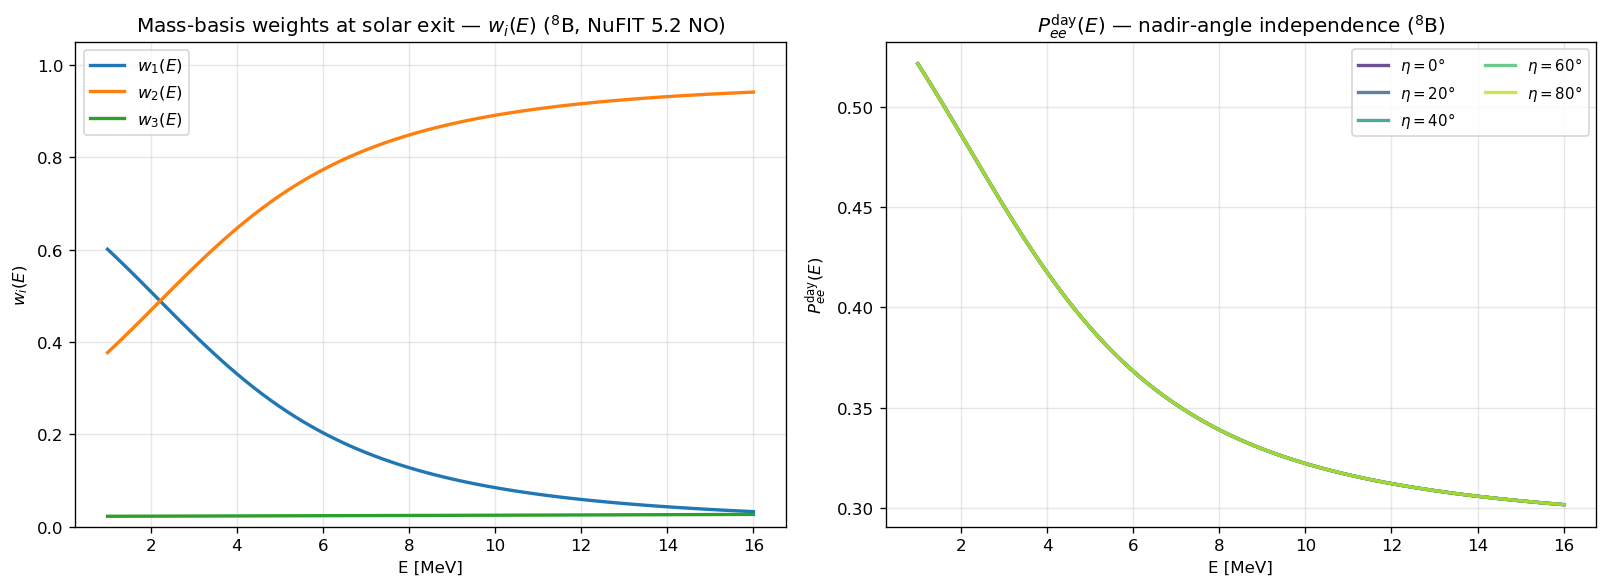

v:\output\analysis\earth\e5_fig31a_pday.png


In [4]:
# Step 1 — solar exit mass weights w_i(E)
W_solar = solar_probability_mass(oscillation, ENERGY_MEV, solar_profile, SOURCE)  # (nE, 3)
W_np    = to_numpy(W_solar)

# Step 2 — daytime flavour probabilities
P_day_full = to_numpy(solar_probability_state(oscillation, ENERGY_MEV, solar_profile, SOURCE))  # (nE, 3)

ETA_DEMO_DEG = [0, 20, 40, 60, 80]
colors_demo  = plt.cm.viridis(np.linspace(0.1, 0.9, len(ETA_DEMO_DEG)))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))

# Left: mass-basis weights
ax = axes[0]
mass_labels = [r'$w_1(E)$', r'$w_2(E)$', r'$w_3(E)$']
for i, (lbl, col) in enumerate(zip(mass_labels, ['C0', 'C1', 'C2'])):
    ax.plot(ENERGY_NP, W_np[:, i], color=col, lw=2.0, label=lbl)
ax.set_xlabel('E [MeV]')
ax.set_ylabel(r'$w_i(E)$')
ax.set_title(r'Mass-basis weights at solar exit — $w_i(E)$ ($^8$B, NuFIT 5.2 NO)')
ax.legend()
ax.set_ylim(0, 1.05)

# Right: P_ee^day vs E for several eta labels — all identical
ax = axes[1]
for deg, col in zip(ETA_DEMO_DEG, colors_demo):
    ax.plot(ENERGY_NP, P_day_full[:, 0], color=col, lw=2.0,
            label=rf'$\eta={deg}°$', alpha=0.8)
ax.set_xlabel('E [MeV]')
ax.set_ylabel(r'$P_{ee}^{\rm day}(E)$')
ax.set_title(r'$P_{ee}^{\rm day}(E)$ — nadir-angle independence ($^8$B)')
ax.legend(fontsize=9, ncol=2)

fig.tight_layout()
save_and_show('e5_fig31a_pday.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

The panel below shows $P_{ee}^{\rm day}$ as a function of nadir angle $\eta$ for several fixed energies. The horizontal lines confirm that the daytime probability is **constant in $\eta$** — a key prerequisite for the asymmetry to be a pure Earth-regeneration effect.

**Expected results:** 
- Perfectly flat lines at values consistent with the LMA prediction:
 *  $P_{ee}^{\rm day}\approx 0.55$ at low $E$ (quasi-vacuum limit)
 *  $P_{ee}^{\rm day}\approx |U_{e2}|^2\approx 0.30$ at high $E$ (adiabatic MSW limit).

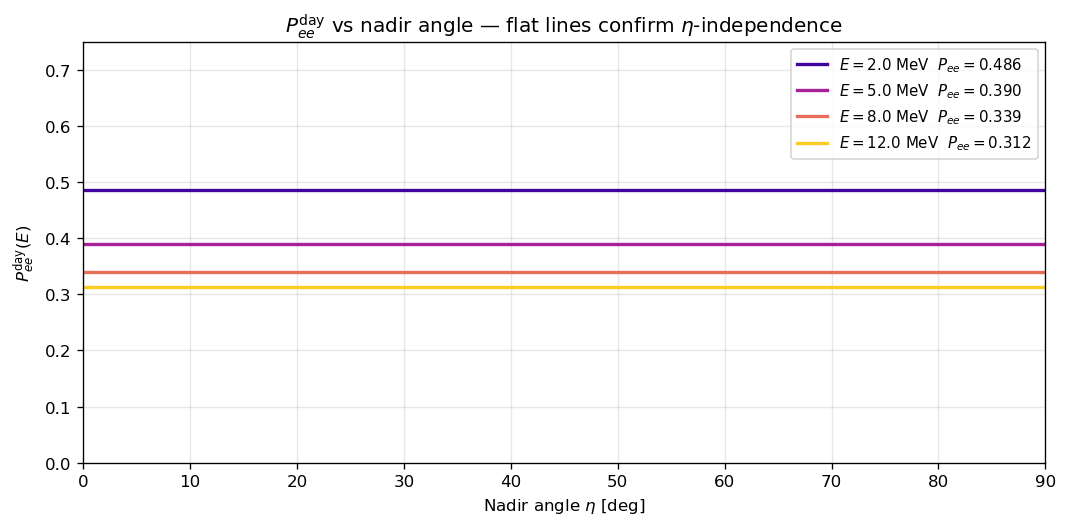

v:\output\analysis\earth\e5_fig31b_pday_vs_eta.png


In [5]:
E_PROBE_DAY   = [2.0, 5.0, 8.0, 12.0]
ETA_DEMO_DEG2 = np.linspace(0, 89, 80)
colors_E_day  = plt.cm.plasma(np.linspace(0.1, 0.9, len(E_PROBE_DAY)))

fig, ax = plt.subplots(figsize=(9, 4.5))
for E_val, col in zip(E_PROBE_DAY, colors_E_day):
    E_t    = torch.tensor(E_val, dtype=ctx.dtype, device=ctx.device)
    pday_E = float(to_numpy(solar_probability_state(oscillation, E_t, solar_profile, SOURCE))[0])
    ax.axhline(pday_E, color=col, lw=2.0, label=rf'$E={E_val}$ MeV  $P_{{ee}}={pday_E:.3f}$')
ax.set_xlabel(r'Nadir angle $\eta$ [deg]')
ax.set_ylabel(r'$P_{ee}^{\rm day}(E)$')
ax.set_title(r'$P_{ee}^{\rm day}$ vs nadir angle — flat lines confirm $\eta$-independence')
ax.legend(fontsize=9)
ax.set_xlim(0, 90)
ax.set_ylim(0, 0.75)
fig.tight_layout()
save_and_show('e5_fig31b_pday_vs_eta.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 3.2 Nighttime Electron-Neutrino Survival Probability $P_{ee}^{\rm night}(E,\eta)$

The nighttime probability is computed by passing the solar exit mass weights $w_i(E)$ to `earth_probability_state_analytical(..., massbasis=True)`, which applies the Earth evolution operator built from the PREM even-power density profile. The nadir angle $\eta$ determines which Earth layers the neutrinos cross:

| Nadir range | Layers crossed | Chord length |
|-------------|----------------|--------------|
| $\eta\lesssim 11°$ | Inner core + outer core + mantle | $\sim12{,}700$ km |
| $11°\lesssim\eta\lesssim 33°$ | Outer core + mantle | $\sim6{,}000$–$12{,}000$ km |
| $33°\lesssim\eta\lesssim 60°$ | Mantle only | $\sim2{,}000$–$6{,}000$ km |
| $\eta\gtrsim 60°$ | Crust only | $\lesssim 2{,}000$ km |

The left panel shows $P_{ee}^{\rm night}(E,\eta)$ vs energy for each characteristic nadir angle, compared against $P_{ee}^{\rm day}$ (dashed black). The right panel shows $P_{ee}^{\rm night}$ vs nadir at fixed energies, where discontinuities of slope at the inner-core and outer-core boundaries are visible.

**Expected results:**
- Night curves lie **above** the daytime reference for energies above a few MeV  (regeneration increases $P_{ee}$).
- Deeper trajectories (smaller $\eta$) show a stronger regeneration effect.
- The $\eta$-scan shows slope kinks at $\eta_{\rm IC}\approx 11°$ and  $\eta_{\rm OC}\approx 33°$ — signatures of the density jumps at core boundaries.

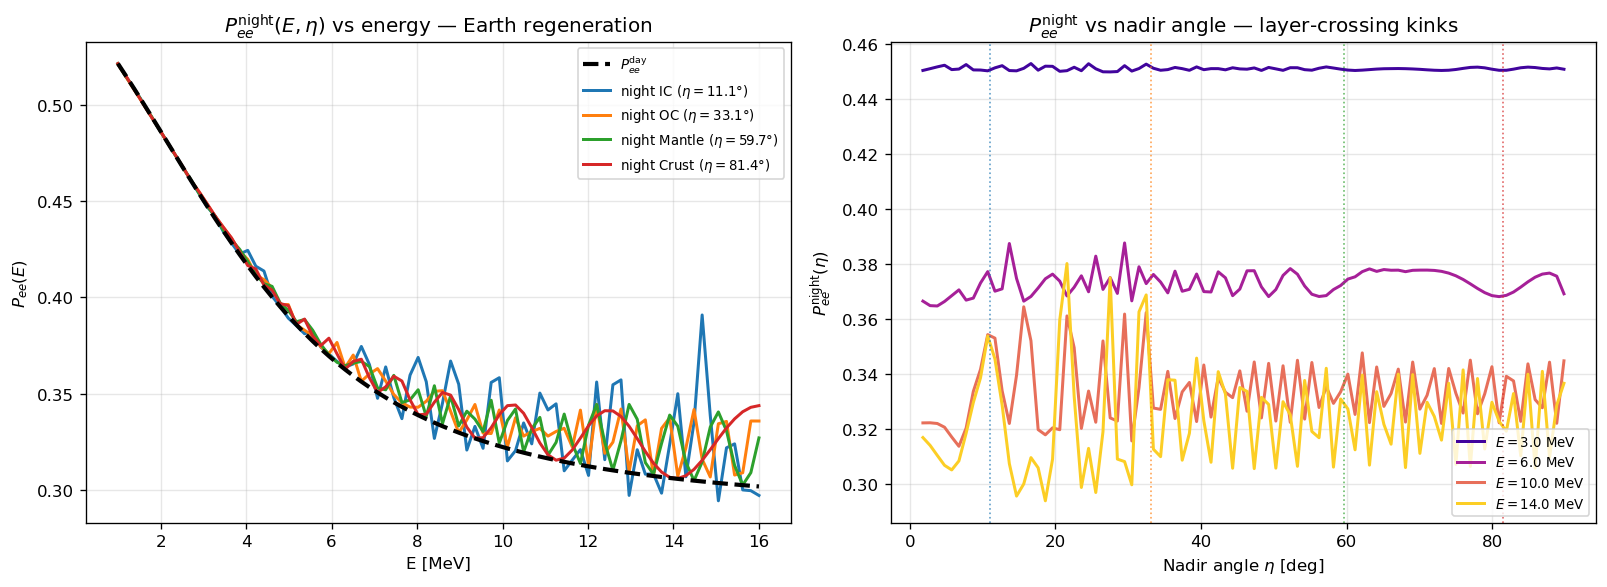

v:\output\analysis\earth\e5_fig32_pnight.png


In [6]:
# Nighttime probability for all named nadir angles — vectorised over energy
P_night_dict = {}  # (eta_val, label) -> (numpy array (nE,3), color)
for eta_val, label, col in NAMED_ETAS:
    eta_t = torch.tensor(eta_val, dtype=ctx.dtype, device=ctx.device)
    P_n = earth_probability_state_analytical(
        W_solar, earth_profile, oscillation, ENERGY_MEV, eta_t, EARTH_DEPTH_M,
        massbasis=True,
    )  # (nE, 3)
    P_night_dict[(eta_val, label)] = (to_numpy(P_n), col)

# P_ee^night vs eta at fixed energies (scalar E loop)
ETA_SWEEP     = np.linspace(0.01 * math.pi, 0.499 * math.pi, 90)
E_PROBE_NIGHT = [3.0, 6.0, 10.0, 14.0]
colors_En     = plt.cm.plasma(np.linspace(0.1, 0.9, len(E_PROBE_NIGHT)))

P_night_vs_eta = {}  # E_val -> numpy (90,)
for E_val in E_PROBE_NIGHT:
    E_t  = torch.tensor(E_val, dtype=ctx.dtype, device=ctx.device)
    w_E  = solar_probability_mass(oscillation, E_t, solar_profile, SOURCE)  # (3,)
    P_arr = np.zeros(len(ETA_SWEEP))
    for ie, eta in enumerate(ETA_SWEEP):
        eta_t = torch.tensor(eta, dtype=ctx.dtype, device=ctx.device)
        P_arr[ie] = float(to_numpy(earth_probability_state_analytical(
            w_E, earth_profile, oscillation, E_t, eta_t, EARTH_DEPTH_M,
            massbasis=True,
        ))[0])
    P_night_vs_eta[E_val] = P_arr

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))

# Left: P_ee^night vs E
ax = axes[0]
ax.plot(ENERGY_NP, P_day_full[:, 0], 'k--', lw=2.5, label=r'$P_{ee}^{\rm day}$', zorder=10)
for (eta_val, label), (P_arr, col) in P_night_dict.items():
    ax.plot(ENERGY_NP, P_arr[:, 0], color=col, lw=1.8, label=rf'night {label}')
ax.set_xlabel('E [MeV]')
ax.set_ylabel(r'$P_{ee}(E)$')
ax.set_title(r'$P_{ee}^{\rm night}(E,\eta)$ vs energy — Earth regeneration')
ax.legend(fontsize=8)

# Right: P_ee^night vs eta
ax = axes[1]
eta_deg_plot = np.degrees(ETA_SWEEP)
for E_val, col in zip(E_PROBE_NIGHT, colors_En):
    ax.plot(eta_deg_plot, P_night_vs_eta[E_val], color=col, lw=1.8,
            label=rf'$E={E_val}$ MeV')
for eta_val, label, col in NAMED_ETAS:
    ax.axvline(math.degrees(eta_val), color=col, ls=":", lw=1.0, alpha=0.7)
ax.set_xlabel(r'Nadir angle $\eta$ [deg]')
ax.set_ylabel(r'$P_{ee}^{\rm night}(\eta)$')
ax.set_title(r'$P_{ee}^{\rm night}$ vs nadir angle — layer-crossing kinks')
ax.legend(fontsize=8)

fig.tight_layout()
save_and_show('e5_fig32_pnight.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 3.3 Nighttime Probability Heatmap $P_{ee}^{\rm night}(E, \eta)$

The full $(E, \eta)$ landscape of the Earth-regenerated survival probability is shown as a pair of 2D heatmaps. The left panel shows $P_{ee}^{\rm night}$ directly; the right panel shows the pure Earth regeneration contribution $\Delta P_{ee} = P_{ee}^{\rm night} - P_{ee}^{\rm day}$, with the zero contour (black line) separating regeneration from suppression regions.
 Vertical dashed lines mark the PREM density discontinuities.

These arrays (`P_heat`, `P_day_heat`, `E_HEAT`, `ETA_HEAT`) are retained in the notebook namespace for reuse in § 5.3.

**Expected results:**
- $P_{ee}^{\rm night} \to P_{ee}^{\rm day}$ as $\eta \to 90°$ (no Earth crossing).
- Regeneration $\Delta P_{ee} > 0$ covers most of the $(E > 3\,\rm MeV,\,  \eta < 60°)$ plane.
- The strongest regeneration occurs at small $\eta$ (deep core crossing) and  high $E$ where the MSW effect is largest.

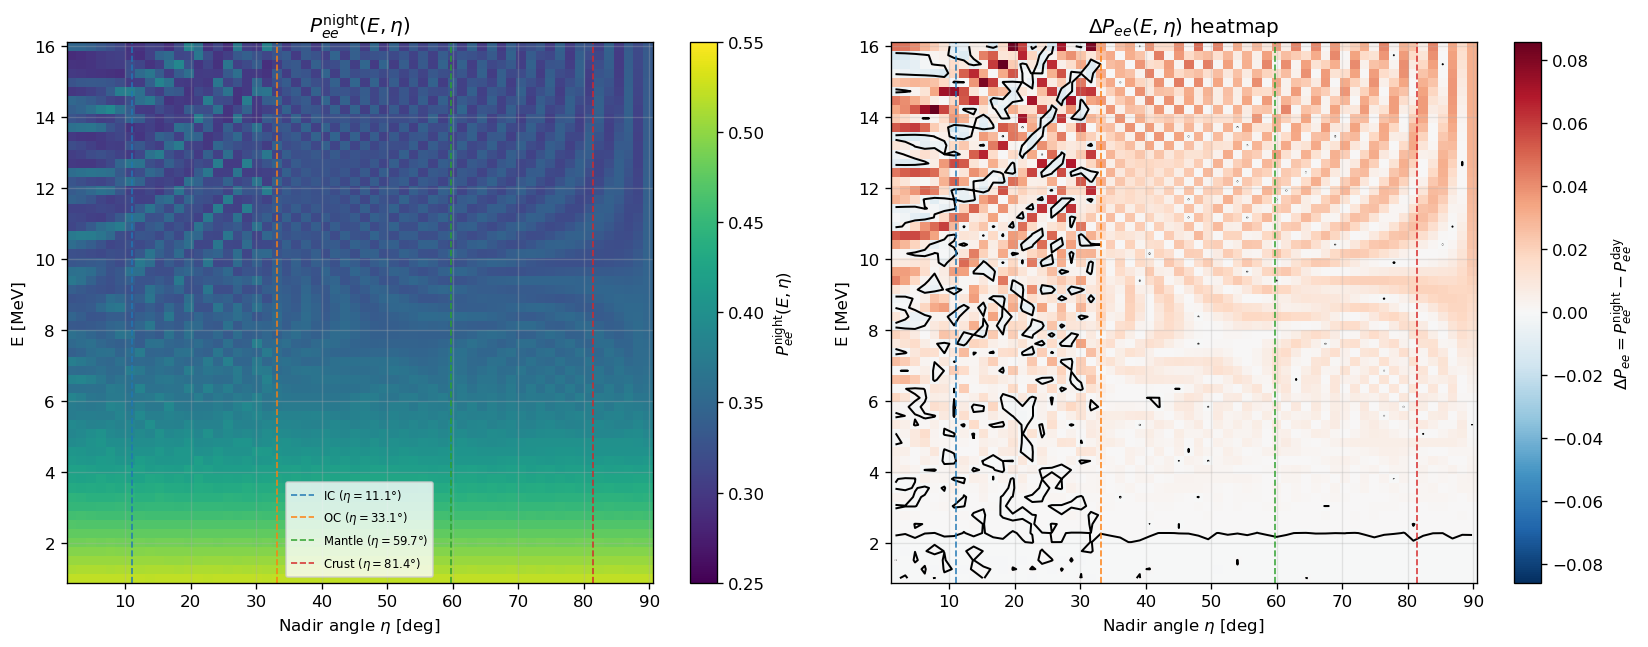

v:\output\analysis\earth\e5_fig33_pnight_heatmap.png


In [7]:
# 2D grid for heatmap
E_HEAT    = torch.linspace(1.0, 16.0, 60, dtype=ctx.dtype, device=ctx.device)
ETA_HEAT  = np.linspace(0.01 * math.pi, 0.499 * math.pi, 60)
E_HEAT_NP = to_numpy(E_HEAT)

W_HEAT     = solar_probability_mass(oscillation, E_HEAT, solar_profile, SOURCE)  # (60, 3)
P_day_heat = to_numpy(solar_probability_state(oscillation, E_HEAT, solar_profile, SOURCE))[:, 0]  # (60,)

P_heat = np.zeros((len(E_HEAT), len(ETA_HEAT)))
for ie, eta in enumerate(ETA_HEAT):
    eta_t = torch.tensor(eta, dtype=ctx.dtype, device=ctx.device)
    P_heat[:, ie] = to_numpy(earth_probability_state_analytical(
        W_HEAT, earth_profile, oscillation, E_HEAT, eta_t, EARTH_DEPTH_M,
        massbasis=True,
    ))[:, 0]

delta_P_heat = P_heat - P_day_heat[:, None]  # (nE, neta)
eta_deg_heat = np.degrees(ETA_HEAT)
vabs         = np.max(np.abs(delta_P_heat))

fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.5))

# Left: P_ee^night
ax = axes[0]
im0 = ax.pcolormesh(eta_deg_heat, E_HEAT_NP, P_heat,
                    shading="auto", cmap="viridis", vmin=0.25, vmax=0.55)
fig.colorbar(im0, ax=ax, label=r'$P_{ee}^{\rm night}(E, \eta)$')
for eta_val, label, col in NAMED_ETAS:
    ax.axvline(math.degrees(eta_val), color=col, ls="--", lw=1.0, alpha=0.9, label=label)
ax.set_xlabel(r'Nadir angle $\eta$ [deg]')
ax.set_ylabel("E [MeV]")
ax.set_title(r'$P_{ee}^{\rm night}(E, \eta)$')
ax.legend(fontsize=7)

# Right: Delta P (regeneration)
ax = axes[1]
im1 = ax.pcolormesh(eta_deg_heat, E_HEAT_NP, delta_P_heat,
                    shading="auto", cmap="RdBu_r", vmin=-vabs, vmax=vabs)
fig.colorbar(im1, ax=ax, label=r'$\Delta P_{ee} = P_{ee}^{\rm night} - P_{ee}^{\rm day}$')
ax.contour(eta_deg_heat, E_HEAT_NP, delta_P_heat, levels=[0],
           colors="k", linewidths=1.2)
for eta_val, label, col in NAMED_ETAS:
    ax.axvline(math.degrees(eta_val), color=col, ls="--", lw=1.0, alpha=0.9)
ax.set_xlabel(r'Nadir angle $\eta$ [deg]')
ax.set_ylabel("E [MeV]")
ax.set_title(r'$\Delta P_{ee}(E, \eta)$ heatmap')

fig.tight_layout()
save_and_show("e5_fig33_pnight_heatmap.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 4. Day-Night Spectral Comparison

### 4.1 Day vs Night Spectra

Both probabilities are overlaid on the same axes: the solid black curve is $P_{ee}^{\rm day}(E)$ and the coloured dashed curves are $P_{ee}^{\rm night}(E,\eta)$ for each characteristic nadir angle. The grey band marks the typical Super-K $^8$B analysis energy range ($>5$ MeV).

**Expected results:** 
- The night curves approach the day curve at low $E$ (both approach the quasi-vacuum limit $\sum_i|U_{ei}|^4\approx 0.55$)
- The night curves diverge at high $E$ where Earth regeneration is strongest.
- Core-crossing trajectories (IC, OC) show the largest night-day difference.

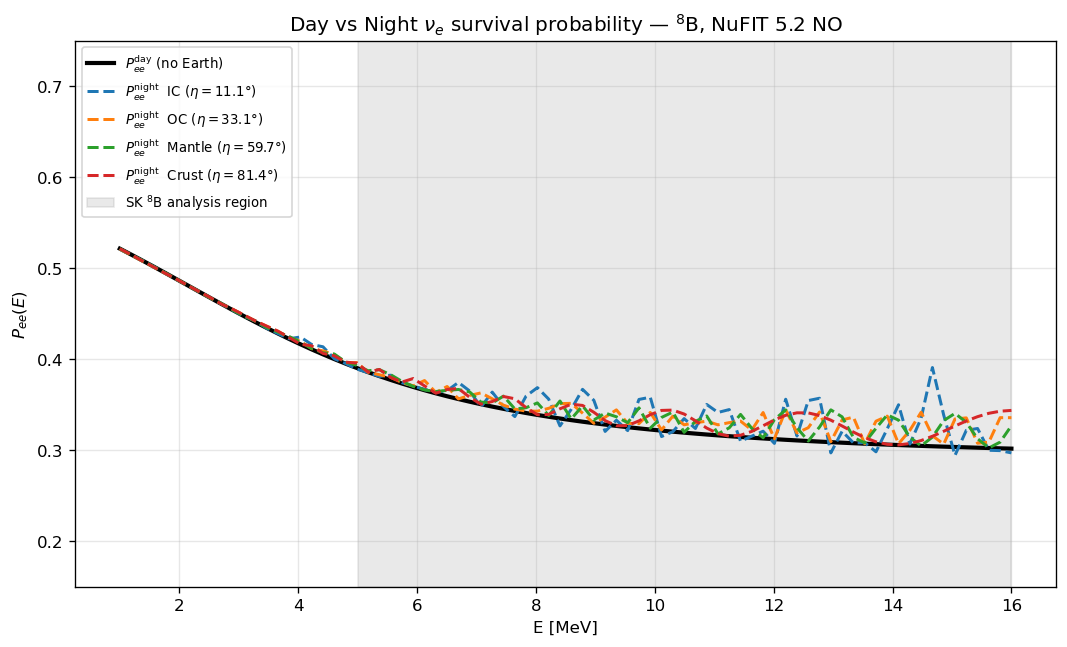

v:\output\analysis\earth\e5_fig41_day_vs_night.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(ENERGY_NP, P_day_full[:, 0], 'k-', lw=2.5, label=r'$P_{ee}^{\rm day}$ (no Earth)')
for (eta_val, label), (P_arr, col) in P_night_dict.items():
    ax.plot(ENERGY_NP, P_arr[:, 0], color=col, lw=1.8, ls='--',
            label=rf'$P_{{ee}}^{{\rm night}}$  {label}')
ax.axvspan(5.0, 16.0, alpha=0.17, color='gray', label='SK $^8$B analysis region')
ax.set_xlabel('E [MeV]')
ax.set_ylabel(r'$P_{ee}(E)$')
ax.set_title(r'Day vs Night $\nu_e$ survival probability — $^8$B, NuFIT 5.2 NO')
ax.legend(fontsize=8)
ax.set_ylim(0.15, 0.75)
fig.tight_layout()
save_and_show('e5_fig41_day_vs_night.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 4.2 Spectral Difference and Regeneration Factor

Two complementary quantities characterise the Earth effect:

**Spectral difference** $\Delta P_{ee}(E,\eta) = P_{ee}^{\rm night}(E,\eta) - P_{ee}^{\rm day}(E)$: directly shows the sign and magnitude of regeneration in probability units.

**Regeneration factor** $f_{\rm reg}(E,\eta) = \dfrac{P_{ee}^{\rm night}(E,\eta) - P_{ee}^{\rm day}(E)}{2\sin^2\theta_{12}}$: normalises the effect by the vacuum solar-mixing scale, making it independent of the overall $P_{ee}$ level and directly comparable across mixing scenarios.

**Expected results:**
- $\Delta P_{ee} > 0$ (regeneration) above $\sim$2–3 MeV, growing with energy.
- $f_{\rm reg}$ saturates at $\sim$0.05–0.15 for core-crossing trajectories at 15 MeV.
- Core-crossing (IC) shows the largest $f_{\rm reg}$; crust-only trajectories show  $|\Delta P_{ee}|\lesssim 0.01$.

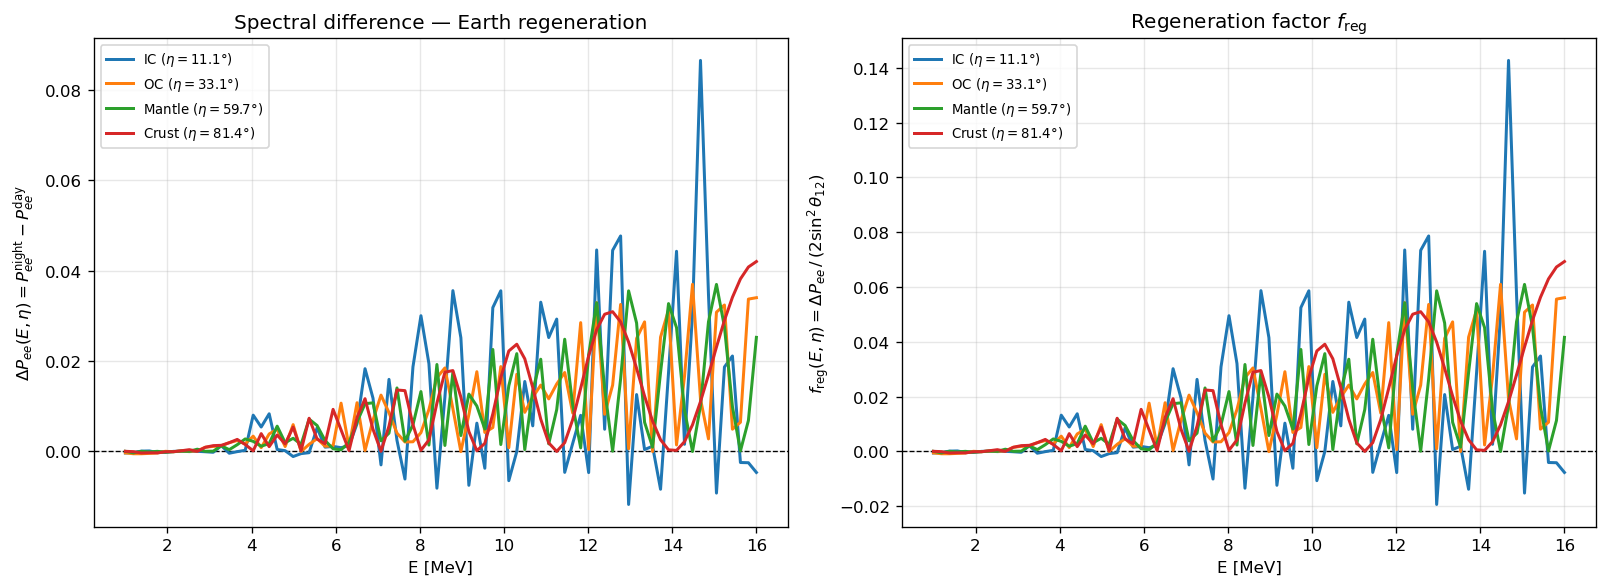

v:\output\analysis\earth\e5_fig42_regeneration.png


In [9]:
sin2_th12 = float(torch.sin(oscillation.pmns.params.theta12) ** 2)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))

# Left: spectral difference
ax = axes[0]
ax.axhline(0, color="k", lw=0.8, ls="--")
for (eta_val, label), (P_arr, col) in P_night_dict.items():
    dP = P_arr[:, 0] - P_day_full[:, 0]
    ax.plot(ENERGY_NP, dP, color=col, lw=1.8, label=label)
ax.set_xlabel('E [MeV]')
ax.set_ylabel(r'$\Delta P_{ee}(E,\eta) = P_{ee}^{\rm night} - P_{ee}^{\rm day}$')
ax.set_title('Spectral difference — Earth regeneration')
ax.legend(fontsize=8)

# Right: regeneration factor
ax = axes[1]
ax.axhline(0, color="k", lw=0.8, ls="--")
for (eta_val, label), (P_arr, col) in P_night_dict.items():
    f_reg = (P_arr[:, 0] - P_day_full[:, 0]) / (2.0 * sin2_th12)
    ax.plot(ENERGY_NP, f_reg, color=col, lw=1.8, label=label)
ax.set_xlabel('E [MeV]')
ax.set_ylabel(r'$f_{\rm reg}(E,\eta) = \Delta P_{ee}\,/\,(2\sin^2\theta_{12})$')
ax.set_title(r'Regeneration factor $f_{\rm reg}$')
ax.legend(fontsize=8)

fig.tight_layout()
save_and_show('e5_fig42_regeneration.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 5. Day-Night Asymmetry $A_{\rm DN}$ vs Energy and Nadir

This section presents the day-night asymmetry as functions of both energy and nadir angle. § 5.1 sweeps $E$ at fixed $\eta$ (nadir-angle families); § 5.2 sweeps $\eta$ at fixed $E$ revealing layer-crossing kinks; § 5.3 shows the full $(E, \eta)$ landscape as a 2D heatmap.

### 5.1 $A_{\rm DN}(E)$ vs Energy at Fixed Nadir Angles

The day-night asymmetry $A_{\rm DN}$ is plotted as a function of energy for each characteristic nadir angle. The shaded band and dashed line show the Super-K IV measurement $A_{\rm DN} = (-3.2 \pm 1.2)\%$ above 3.5 MeV (Abe et al. 2016).

**Expected results:**
- $A_{\rm DN} < 0$ (night $>$ day) for $E \gtrsim 3$ MeV in the LMA regime.
- The magnitude increases monotonically with energy up to $\sim$15 MeV.
- Deeper Earth crossings (IC, OC) give larger $|A_{\rm DN}|$.
- At very low $E$ ($\lesssim$ 2 MeV) the quasi-vacuum limit gives  $\Delta P \approx 0$.

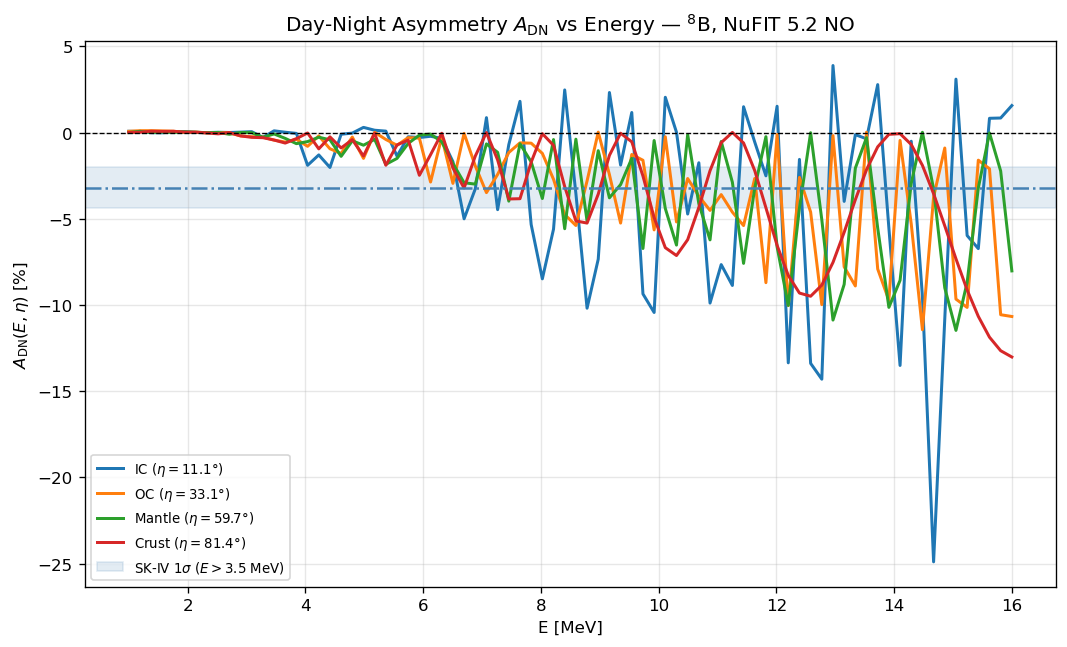

v:\output\analysis\earth\e5_fig5_adn_energy.png


In [10]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for (eta_val, label), (P_arr, col) in P_night_dict.items():
    P_d  = P_day_full[:, 0]
    P_n  = P_arr[:, 0]
    A_DN = 2.0 * (P_d - P_n) / (P_d + P_n) * 100  # percent
    ax.plot(ENERGY_NP, A_DN, color=col, lw=1.8, label=label)
ax.axhline(0, color="k", lw=0.8, ls="--")
# SK-IV reference band
ax.axhspan(-3.2 - 1.2, -3.2 + 1.2, alpha=0.15, color="steelblue",
            label=r'SK-IV $1\sigma$ ($E>3.5$ MeV)')
ax.axhline(-3.2, color="steelblue", lw=1.5, ls="-.")
ax.set_xlabel('E [MeV]')
ax.set_ylabel(r'$A_{\rm DN}(E,\eta)$ [%]')
ax.set_title(r'Day-Night Asymmetry $A_{\rm DN}$ vs Energy — $^8$B, NuFIT 5.2 NO')
ax.legend(fontsize=8)
fig.tight_layout()
save_and_show('e5_fig5_adn_energy.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 5.2 $A_{\rm DN}(\eta)$ vs Nadir Angle at Fixed Energies

At fixed neutrino energy, $A_{\rm DN}(\eta)$ is plotted as a continuous function of nadir angle. Vertical dotted lines mark the inner-core (IC) and outer-core (OC) nadir boundaries. Slope discontinuities at these boundaries are signatures of the density jumps in the PREM profile.

**Expected results:**
- $|A_{\rm DN}|$ is largest for small $\eta$ (deep trajectories) and decreases  monotonically toward $\eta \to 90°$ (surface-grazing, no Earth effect).
- A visible kink occurs at $\eta_{\rm OC}\approx 33°$ (transition from  mantle-only to core-crossing regime).
- Higher energies give larger $|A_{\rm DN}|$ at all $\eta$ values.

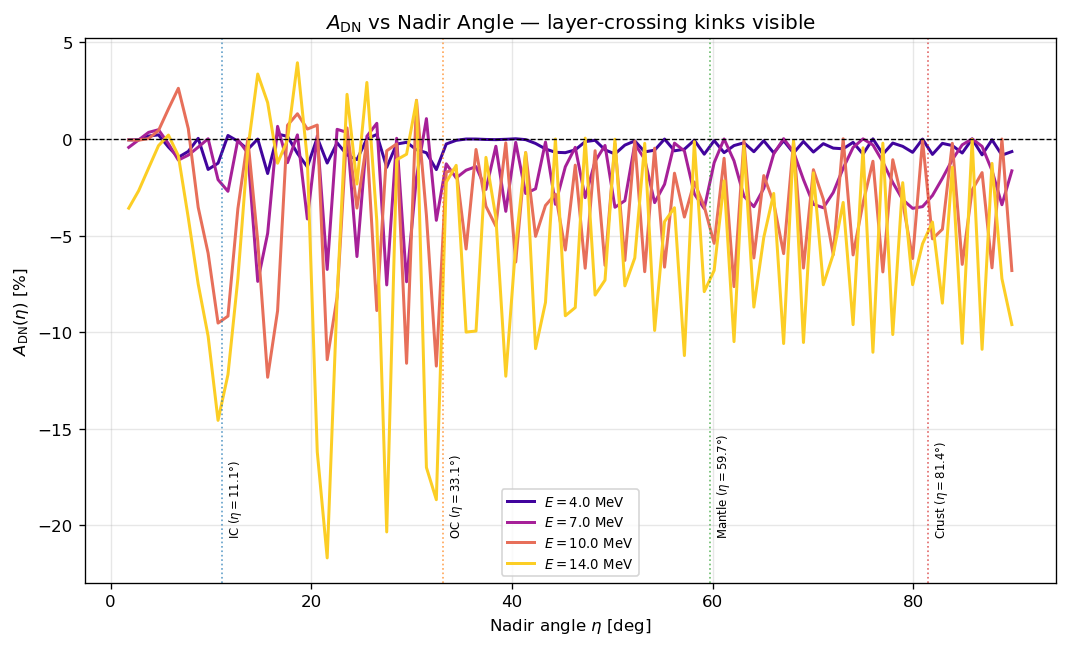

v:\output\analysis\earth\e5_fig6_adn_nadir.png


In [11]:
E_PROBE_ADN   = [4.0, 7.0, 10.0, 14.0]
ETA_SWEEP_ADN = np.linspace(0.01 * math.pi, 0.499 * math.pi, 90)
colors_adn    = plt.cm.plasma(np.linspace(0.1, 0.9, len(E_PROBE_ADN)))

fig, ax = plt.subplots(figsize=(9, 5.5))
for E_val, col in zip(E_PROBE_ADN, colors_adn):
    E_t = torch.tensor(E_val, dtype=ctx.dtype, device=ctx.device)
    w_E = solar_probability_mass(oscillation, E_t, solar_profile, SOURCE)  # (3,)
    P_d = float(to_numpy(solar_probability_state(oscillation, E_t, solar_profile, SOURCE))[0])
    A_eta = np.zeros(len(ETA_SWEEP_ADN))
    for ie, eta in enumerate(ETA_SWEEP_ADN):
        eta_t = torch.tensor(eta, dtype=ctx.dtype, device=ctx.device)
        P_n = float(to_numpy(earth_probability_state_analytical(
            w_E, earth_profile, oscillation, E_t, eta_t, EARTH_DEPTH_M,
            massbasis=True,
        ))[0])
        A_eta[ie] = 2.0 * (P_d - P_n) / (P_d + P_n) * 100
    ax.plot(np.degrees(ETA_SWEEP_ADN), A_eta, color=col, lw=1.8,
            label=rf'$E={E_val}$ MeV')
for eta_val, label, col in NAMED_ETAS:
    ax.axvline(math.degrees(eta_val), color=col, ls=":", lw=1.0, alpha=0.7)
    ax.text(math.degrees(eta_val) + 0.5, ax.get_ylim()[0] * 0.9, label,
            fontsize=7, rotation=90, va="bottom")
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_xlabel(r'Nadir angle $\eta$ [deg]')
ax.set_ylabel(r'$A_{\rm DN}(\eta)$ [%]')
ax.set_title(r'$A_{\rm DN}$ vs Nadir Angle — layer-crossing kinks visible')
ax.legend(fontsize=8)
fig.tight_layout()
save_and_show('e5_fig6_adn_nadir.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 5.3 $A_{\rm DN}(E, \eta)$ Heatmap

The complete $(E, \eta)$ day-night asymmetry landscape is shown as a 2D heatmap, using the $P_{ee}^{\rm night}$ matrix computed in § 3.3. Blue regions correspond to $A_{\rm DN} < 0$ (regeneration increases the night rate); the black dashed contour marks $A_{\rm DN} = 0$. Vertical dotted lines mark the PREM layer boundaries.

**Expected results:**
- The most negative $A_{\rm DN}$ (deepest blue) occurs at small $\eta$ and  high $E$ — core-crossing, high-energy region.
- The $A_{\rm DN} = 0$ contour runs diagonally from low $\eta$/low $E$ to  higher $\eta$/higher $E$, tracing where the Earth effect changes sign.
- At large $\eta$ (crust-only trajectories), $A_{\rm DN} \approx 0$ across  all energies.

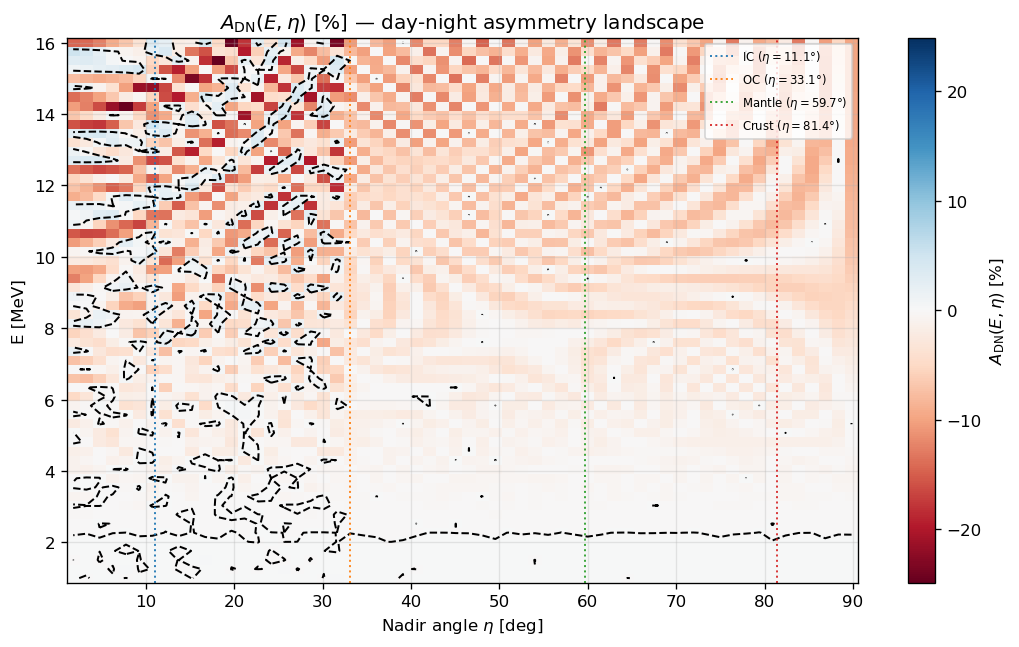

v:\output\analysis\earth\e5_fig53_adn_heatmap.png


In [12]:
# A_DN heatmap — reuse P_heat and P_day_heat from § 3.3
P_day_heat_2d = P_day_heat[:, None]  # broadcast: (nE, 1)
A_heat = 2.0 * (P_day_heat_2d - P_heat) / (P_day_heat_2d + P_heat) * 100  # (nE, neta) [%]

vabs_a = max(float(np.abs(A_heat).max()), 0.5)

fig, ax = plt.subplots(figsize=(9.0, 5.5))
im = ax.pcolormesh(eta_deg_heat, E_HEAT_NP, A_heat,
                   shading="auto", cmap="RdBu", vmin=-vabs_a, vmax=vabs_a)
fig.colorbar(im, ax=ax, label=r'$A_{\rm DN}(E, \eta)$ [%]')
ax.contour(eta_deg_heat, E_HEAT_NP, A_heat, levels=[0],
           colors="k", linewidths=1.2, linestyles="--")
for eta_val, label, col in NAMED_ETAS:
    ax.axvline(math.degrees(eta_val), color=col, ls=":", lw=1.2, alpha=0.9, label=label)
ax.set_xlabel(r'Nadir angle $\eta$ [deg]')
ax.set_ylabel("E [MeV]")
ax.set_title(r'$A_{\rm DN}(E, \eta)$ [%] — day-night asymmetry landscape')
ax.legend(fontsize=7, loc="upper right")
fig.tight_layout()
save_and_show("e5_fig53_adn_heatmap.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 6. Exposure-Averaged Asymmetry $\langle A_{\rm DN}\rangle$

### 6.1 Per-Detector Energy Spectra

`earth_probability_exposure` folds $P_{ee}^{\rm night}(E,\eta)$ with the detector's nadir-angle night exposure distribution $W_{\rm night}(\eta)$ (built from the geographic latitude, as detailed in *Earth4*). The result $\langle P_{ee}^{\rm night}\rangle(E)$ is the quantity directly comparable to experimental measurements.

The left panel shows $\langle P_{ee}^{\rm night}\rangle(E)$ per detector alongside $P_{ee}^{\rm day}(E)$. The right panel shows the corresponding $\langle A_{\rm DN}\rangle(E)$.

**Expected results:**
- $\langle A_{\rm DN}\rangle$ is negative and $\lesssim 4\%$ in magnitude for  all detectors.
- Detectors at higher latitude (SNO+) see more grazing nadir angles on average,  reducing $|\langle A_{\rm DN}\rangle|$.
- The energy dependence follows the single-$\eta$ curves, shifted toward smaller  magnitudes due to the exposure averaging.

Super-K     <P_ee^night> at 10 MeV ≈ 0.3306
Borexino    <P_ee^night> at 10 MeV ≈ 0.3304
SNO+        <P_ee^night> at 10 MeV ≈ 0.3310
JUNO        <P_ee^night> at 10 MeV ≈ 0.3297


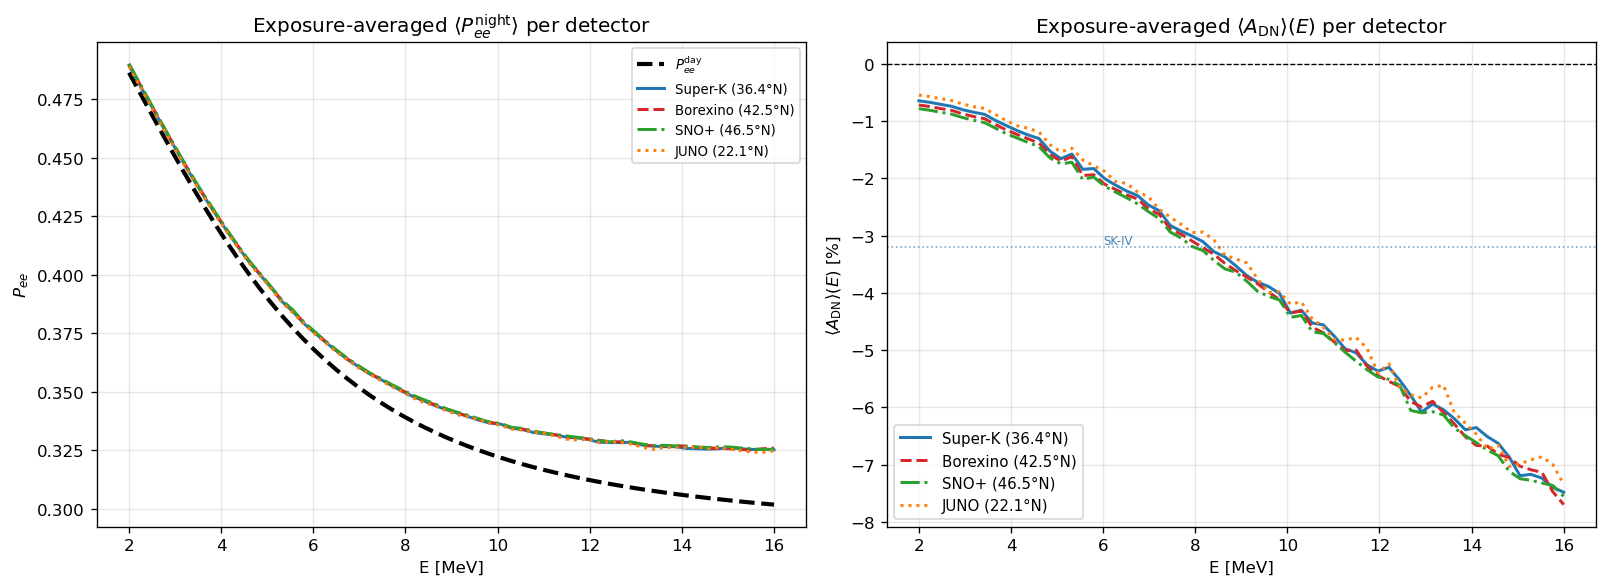

v:\output\analysis\earth\e5_fig7_adn_exposure.png


In [13]:
E_INT    = torch.linspace(2.0, 16.0, 60, dtype=ctx.dtype, device=ctx.device)
E_INT_NP = to_numpy(E_INT)
W_8B_INT = solar_probability_mass(oscillation, E_INT, solar_profile, SOURCE)  # (nE, 3)
P_day_int = to_numpy(solar_probability_state(oscillation, E_INT, solar_profile, SOURCE))[:, 0]   # (nE,)

P_avg_det = {}
for det_name, det_info in DETECTORS.items():
    lat_rad = math.radians(det_info["lat_deg"])
    P_avg = earth_probability_exposure(
        W_8B_INT, earth_profile, oscillation, E_INT, EARTH_DEPTH_M,
        method="analytical", massbasis=True,
        exposure=ExposureParameters(
            detector_latitude_rad=lat_rad,
            exposure_daynight="night",
            exposure_ns=200,
        ),
        normalized_exposure=True,
        context=ctx,
    )  # (nE, 3)
    P_avg_det[det_name] = to_numpy(P_avg)[:, 0]
    print(f'{det_name:10s}  <P_ee^night> at 10 MeV ≈ {float(P_avg_det[det_name][40]):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))

# Left: P_ee per detector
ax = axes[0]
ax.plot(E_INT_NP, P_day_int, 'k--', lw=2.5, label=r'$P_{ee}^{\rm day}$')
for det_name, P_avg in P_avg_det.items():
    info = DETECTORS[det_name]
    ax.plot(E_INT_NP, P_avg, color=info['color'], ls=info['ls'], lw=1.8,
            label=f'{det_name} ({info["lat_deg"]:.1f}°N)'
           )
ax.set_xlabel('E [MeV]')
ax.set_ylabel(r'$P_{ee}$')
ax.set_title(r'Exposure-averaged $\langle P_{ee}^{\rm night}\rangle$ per detector')
ax.legend(fontsize=8)

# Right: <A_DN> per detector
ax = axes[1]
for det_name, P_avg in P_avg_det.items():
    info = DETECTORS[det_name]
    A_dn = 2.0 * (P_day_int - P_avg) / (P_day_int + P_avg) * 100
    ax.plot(E_INT_NP, A_dn, color=info['color'], ls=info['ls'], lw=1.8,
            label=rf'{det_name} ({info["lat_deg"]:.1f}°N)')
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.axhline(-3.2, color="steelblue", lw=1.0, ls=":", alpha=0.7)
ax.annotate(r'SK-IV', xy=(6, -3.2), fontsize=7, color='steelblue', va='bottom')
ax.set_xlabel('E [MeV]')
ax.set_ylabel(r'$\langle A_{\rm DN}\rangle(E)$ [%]')
ax.set_title(r'Exposure-averaged $\langle A_{\rm DN}\rangle(E)$ per detector')
ax.legend(fontsize=9)

fig.tight_layout()
save_and_show('e5_fig7_adn_exposure.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 6.2 Integrated Day-Night Asymmetry $A_{\rm DN}^{\rm int}$

The energy-integrated asymmetry weights $P_{ee}$ by the $^8$B spectral flux $g_{^8B}(E)$ (loaded from `data/solar/spectra/spectrum_8B.csv`) and integrates above an energy threshold $E_{\rm thr}$:

$$A_{\rm DN}^{\rm int} = 2\,\frac{\int_{E_{\rm thr}} dE\;g_{^8B}(E)\,P_{ee}^D(E) - \int_{E_{\rm thr}} dE\;g_{^8B}(E)\,\langle P_{ee}^N(E)\rangle_\eta}{\int_{E_{\rm thr}} dE\;g_{^8B}(E)\,P_{ee}^D(E) + \int_{E_{\rm thr}} dE\;g_{^8B}(E)\,\langle P_{ee}^N(E)\rangle_\eta}$$

This is the quantity most directly comparable to published experimental results. The table below shows $A_{\rm DN}^{\rm int}$ for each detector at three energy thresholds. The bar chart uses $E_{\rm thr} = 3.5$ MeV (Super-K IV threshold).

**Expected results:**
- $|A_{\rm DN}^{\rm int}|$ of order 1–3\% for realistic detector latitudes, consistent with the Super-K IV measurement of $(-3.2 \pm 1.2)\%$ at this threshold.

Detector   | no cut       | E>3.5 MeV    | E>5.0 MeV   
----------------------------------------------------------
Super-K    | -2.45 %      | -2.72 %      | -3.07 %     
Borexino   | -2.52 %      | -2.79 %      | -3.15 %     
SNO+       | -2.59 %      | -2.85 %      | -3.21 %     
JUNO       | -2.35 %      | -2.61 %      | -2.97 %     


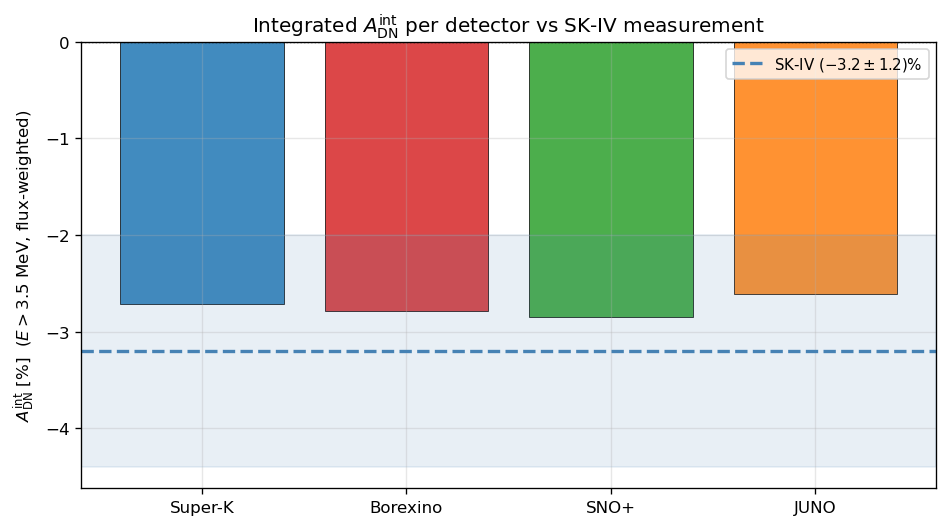

v:\output\analysis\earth\e5_fig62_adn_integrated.png


In [14]:
# Spectral weight: g_8B interpolated on E_INT grid
g_8B_int_arr = np.interp(E_INT_NP, G_8B_E, G_8B_SPEC)  # [MeV^-1]

# Three energy thresholds for comparison
THRESHOLDS = [("no cut", 0.0), ("E > 3.5 MeV", 3.5), ("E > 5.0 MeV", 5.0)]

A_int_results = {}  # det_name -> {label: A_DN_int}
print(f'{"Detector":10s} | {"no cut":12s} | {"E>3.5 MeV":12s} | {"E>5.0 MeV":12s}')
print("-" * 58)
for det_name, P_avg in P_avg_det.items():
    A_int_results[det_name] = {}
    row_vals = []
    for label, E_thr in THRESHOLDS:
        mask = E_INT_NP >= E_thr
        R_d = numpy_trapezoid(g_8B_int_arr[mask] * P_day_int[mask], E_INT_NP[mask])
        R_n = numpy_trapezoid(g_8B_int_arr[mask] * P_avg[mask],    E_INT_NP[mask])
        A   = 2.0 * (R_d - R_n) / (R_d + R_n) * 100
        A_int_results[det_name][label] = A
        row_vals.append(f'{A:+.2f} %')
    print(f'{det_name:10s} | {row_vals[0]:12s} | {row_vals[1]:12s} | {row_vals[2]:12s}')

# Bar chart at E > 3.5 MeV
det_names = list(A_int_results.keys())
adn_vals  = [A_int_results[d]["E > 3.5 MeV"] for d in det_names]
colors_bar = [DETECTORS[d]["color"] for d in det_names]

fig, ax = plt.subplots(figsize=(8.0, 4.5))
ax.bar(det_names, adn_vals, color=colors_bar, alpha=0.85, edgecolor="k", linewidth=0.5)
ax.axhline(-3.2, color="steelblue", ls="--", lw=2.0,
           label=r"SK-IV $(-3.2\pm1.2)\%$")
ax.axhspan(-3.2 - 1.2, -3.2 + 1.2, alpha=0.12, color="steelblue")
ax.axhline(0, color="k", lw=0.8, ls=":")
ax.set_ylabel(r'$A_{\rm DN}^{\rm int}$ [%]  ($E > 3.5$ MeV, flux-weighted)')
ax.set_title(r'Integrated $A_{\rm DN}^{\rm int}$ per detector vs SK-IV measurement')
ax.legend(fontsize=9)
fig.tight_layout()
save_and_show("e5_fig62_adn_integrated.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 7. Detected Level Observable

Real experiments measure an event rate spectrum proportional to the neutrino flux, the detection cross section, and the survival probability. This section builds the full detected-rate model using the actual $^8$B spectral shape from `data/solar/spectra/spectrum_8B.csv` and the flavour-dependent elastic scattering cross section.

### 7.1 Effective Detection Cross Section $\sigma_{\rm eff}(E)$

For Super-K-type water Cherenkov detectors, the dominant channel is neutrino–electron elastic scattering (ES). The effective cross section depends on the survival probability because $\nu_e$ and $\nu_{\mu,\tau}$ scatter with different amplitudes:

$$\sigma_{\rm eff}(E,P_{ee}) = P_{ee}(E)\,\sigma_e(E) + \bigl(1-P_{ee}(E)\bigr)\,\sigma_\mu(E)$$

with the linear approximations (Bahcall & Peña-Garay 2004):

$$\sigma_e(E_\nu) \simeq 9.20\times10^{-45}\,\frac{E_\nu}{\rm MeV}\;\rm cm^2, \qquad\sigma_\mu(E_\nu) \simeq 1.57\times10^{-45}\,\frac{E_\nu}{\rm MeV}\;\rm cm^2$$

Since $P_{ee}^{\rm night} > P_{ee}^{\rm day}$ in the LMA regime (regeneration), $\sigma_{\rm eff}$ is **slightly larger at night** than during the day — the Earth effect amplifies the day–night rate difference beyond the $P_{ee}$ shift alone because $\sigma_e/\sigma_\mu \approx 5.9$.

**Expected results:** relative change $(\sigma_{\rm eff}^{\rm night}/\sigma_{\rm eff}^{\rm day} - 1)$ of order $0.1$–0.5\% at high energy for deep-core trajectories.

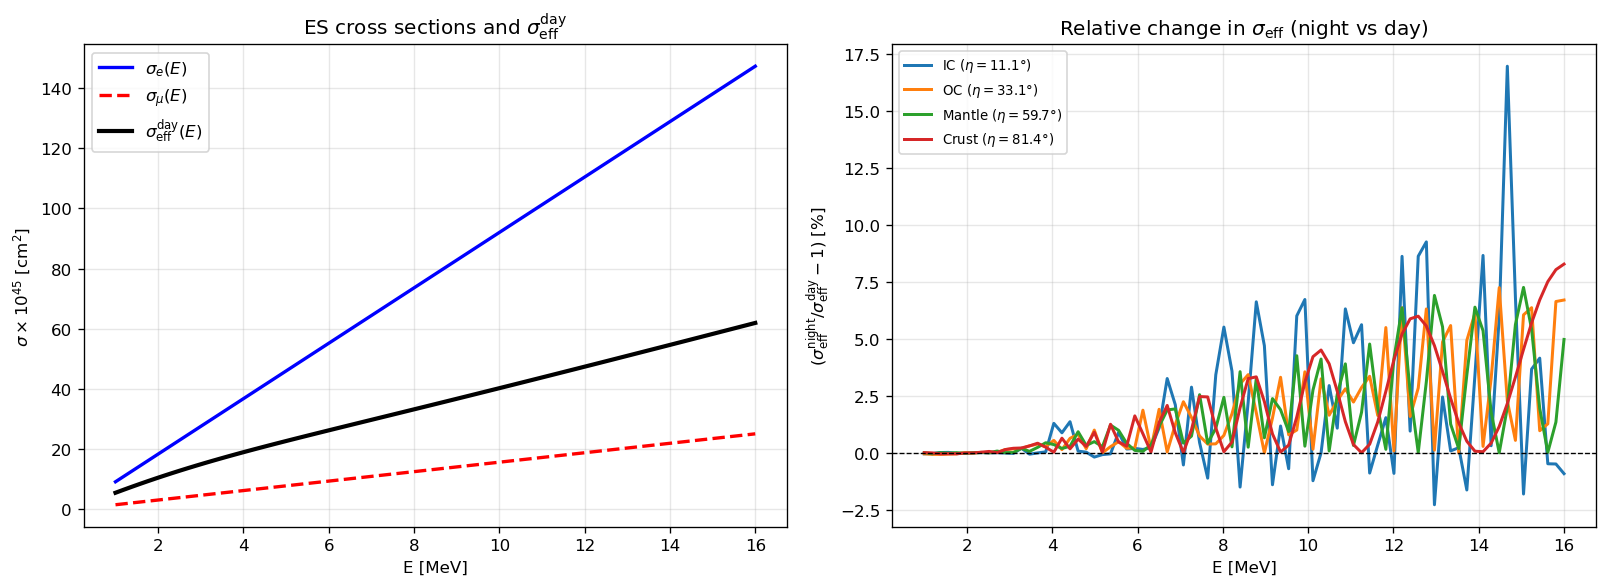

v:\output\analysis\earth\e5_fig71_sigma_eff.png


In [15]:
sigma_e_main  = SIGMA_E_0  * ENERGY_NP  # cm^2
sigma_mu_main = SIGMA_MU_0 * ENERGY_NP  # cm^2
sigma_eff_day_main = (P_day_full[:, 0] * sigma_e_main
                      + (1 - P_day_full[:, 0]) * sigma_mu_main)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))

# Left: individual cross sections and sigma_eff^day
ax = axes[0]
ax.plot(ENERGY_NP, sigma_e_main  * 1e45, "b-",  lw=2.0, label=r'$\sigma_e(E)$')
ax.plot(ENERGY_NP, sigma_mu_main * 1e45, "r--", lw=2.0, label=r'$\sigma_\mu(E)$')
ax.plot(ENERGY_NP, sigma_eff_day_main * 1e45, "k-", lw=2.5,
        label=r'$\sigma_{\rm eff}^{\rm day}(E)$')
ax.set_xlabel("E [MeV]")
ax.set_ylabel(r"$\sigma \times 10^{45}$ [cm$^2$]")
ax.set_title(r'ES cross sections and $\sigma_{\rm eff}^{\rm day}$')
ax.legend()

# Right: relative change sigma_eff^night / sigma_eff^day - 1 [%]
ax = axes[1]
for (eta_val, label), (P_arr, col) in P_night_dict.items():
    sigma_eff_n = (P_arr[:, 0] * sigma_e_main
                  + (1 - P_arr[:, 0]) * sigma_mu_main)
    rel = (sigma_eff_n / sigma_eff_day_main - 1.0) * 100
    ax.plot(ENERGY_NP, rel, color=col, lw=1.8, label=label)
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_xlabel("E [MeV]")
ax.set_ylabel(r"$(\sigma_{\rm eff}^{\rm night}/\sigma_{\rm eff}^{\rm day} - 1)$ [%]")
ax.set_title(r'Relative change in $\sigma_{\rm eff}$ (night vs day)')
ax.legend(fontsize=8)

fig.tight_layout()
save_and_show("e5_fig71_sigma_eff.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 7.2 Rate Spectrum and $A_{\rm DN}$ vs Energy Threshold

The differential detection rate combines the B16 total flux $\Phi_{^8B}$, the normalized spectral shape $g_{^8B}(E)$ from `spectrum_8B.csv` (Bahcall et al. 1996), and the flavour-dependent cross section:

$$\frac{{\rm d}R}{{\rm d}E} = \Phi_{^8B}\;g_{^8B}(E)\;\sigma_{\rm eff}(E,P_{ee}(E))$$

The left panel shows daytime and nighttime rate spectra for Super-K. The right panel shows $\langle A_{\rm DN}\rangle^{\rm det}$ as a function of the energy detection threshold $E_{\rm thr}$.

**Expected results:**
- The night spectrum lies slightly above the day spectrum at high $E$  (both $P_{ee}$ and $\sigma_{\rm eff}$ increase at night).
- $|A_{\rm DN}^{\rm det}|$ grows with $E_{\rm thr}$, since Earth regeneration  is strongest at high energies; optimal threshold is $\sim6$–8 MeV.
- At $E_{\rm thr} = 3.5$ MeV the prediction should bracket the SK-IV  measurement.

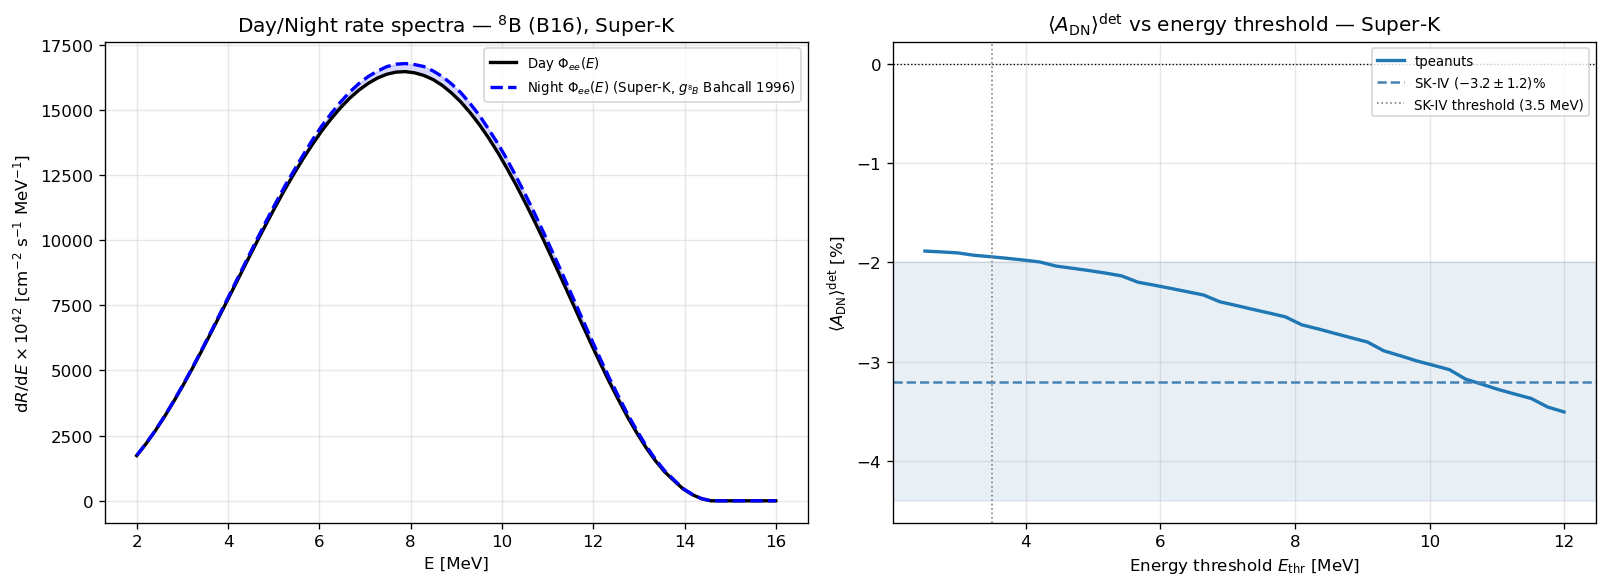

v:\output\analysis\earth\e5_fig72_detected_adn.png


In [16]:
# Detection energy grid
E_DET_MEV = torch.linspace(2.0, 16.0, 70, dtype=ctx.dtype, device=ctx.device)
E_DET_NP  = to_numpy(E_DET_MEV)

# g_8B(E) on detection grid  [MeV^-1]
g_8B_det = np.interp(E_DET_NP, G_8B_E, G_8B_SPEC)

# Day and night P_ee at detection energies
W_det   = solar_probability_mass(oscillation, E_DET_MEV, solar_profile, SOURCE)
P_d_det = to_numpy(solar_probability_state(oscillation, E_DET_MEV, solar_profile, SOURCE))[:, 0]

P_n_sk = to_numpy(earth_probability_exposure(
    W_det, earth_profile, oscillation, E_DET_MEV, EARTH_DEPTH_M,
    method="analytical", massbasis=True,
    exposure=ExposureParameters(
        detector_latitude_rad=math.radians(DETECTORS["Super-K"]["lat_deg"]),
        exposure_daynight="night", exposure_ns=200,
    ),
    normalized_exposure=True, context=ctx,
))[:, 0]

# Effective cross sections  [cm^2]
sigma_e_det  = SIGMA_E_0  * E_DET_NP
sigma_mu_det = SIGMA_MU_0 * E_DET_NP
sigma_eff_d = P_d_det * sigma_e_det  + (1 - P_d_det) * sigma_mu_det
sigma_eff_n = P_n_sk  * sigma_e_det  + (1 - P_n_sk)  * sigma_mu_det

# Rate spectra  [cm^-2 s^-1 MeV^-1]
rate_day   = PHI_8B * g_8B_det * sigma_eff_d
rate_night = PHI_8B * g_8B_det * sigma_eff_n

# A_DN^det vs energy threshold
E_thr_grid = np.linspace(2.5, 12.0, 40)
A_DN_thr   = np.zeros(len(E_thr_grid))
for it, E_thr in enumerate(E_thr_grid):
    mask = E_DET_NP >= E_thr
    if mask.sum() < 2: continue
    R_d = numpy_trapezoid(rate_day[mask],   E_DET_NP[mask])
    R_n = numpy_trapezoid(rate_night[mask], E_DET_NP[mask])
    if R_d + R_n > 0:
        A_DN_thr[it] = 2.0 * (R_d - R_n) / (R_d + R_n) * 100

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))

# Left: rate spectra
ax = axes[0]
ax.plot(E_DET_NP, rate_day   * 1e42, "k-",  lw=2.0,
        label=r'Day $\Phi_{ee}(E)$')
ax.plot(E_DET_NP, rate_night * 1e42, "b--", lw=2.0,
        label=r'Night $\Phi_{ee}(E)$ (Super-K, $g_{^8B}$ Bahcall 1996)')
ax.fill_between(E_DET_NP, rate_day * 1e42, rate_night * 1e42,
                alpha=0.15, color="blue")
ax.set_xlabel("E [MeV]")
ax.set_ylabel(r"${\rm d}R/{\rm d}E \times 10^{42}$ [cm$^{-2}$ s$^{-1}$ MeV$^{-1}$]")
ax.set_title(r'Day/Night rate spectra — $^8$B (B16), Super-K')
ax.legend(fontsize=8)

# Right: A_DN^det vs threshold
ax = axes[1]
ax.plot(E_thr_grid, A_DN_thr, "C0-", lw=2.0, label="tpeanuts")
ax.axhline(-3.2, color="steelblue", lw=1.5, ls="--",
           label=r"SK-IV $(-3.2\pm1.2)\%$")
ax.axhspan(-3.2 - 1.2, -3.2 + 1.2, alpha=0.12, color="steelblue")
ax.axhline(0, color="k", lw=0.8, ls=":")
ax.axvline(3.5, color="gray", ls=":", lw=1.0, label="SK-IV threshold (3.5 MeV)")
ax.set_xlabel(r'Energy threshold $E_{\rm thr}$ [MeV]')
ax.set_ylabel(r"$\langle A_{\rm DN}\rangle^{\rm det}$ [%]")
ax.set_title(r'$\langle A_{\rm DN}\rangle^{\rm det}$ vs energy threshold — Super-K')
ax.legend(fontsize=8)

fig.tight_layout()
save_and_show("e5_fig72_detected_adn.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 7.3 Comparison with Published Measurements

The table below compares three predictions against the experimental measurement.
Values filled in by the code cell below.

| Detector | Lat. | tpeanuts | tpeanuts-sk | LMA std. | Published | Ref. |
|----------|------|----------|-------------|----------|-----------|------|
| Super-K | 36.4°N | *code* | *code* | (−1.7 to −2.0)% | (−3.2 ± 1.2)% | Abe et al. 2016 |
| Borexino | 42.5°N | *code* | *code* | — | — | — |
| SNO+ | 46.5°N | *code* | *code* | — | — | — |
| JUNO | 22.1°N | *code* | *code* | — | — | — |

**Column definitions:**

- **tpeanuts**: $A_{\rm DN}^{\rm int}$ integrated above $E_\nu > 3.5$ MeV, weighted by the normalised spectral shape $g_{^8B}(E)$ only.
- **tpeanuts-sk**: SK-equivalent calculation with two corrections (i) effective neutrino energy threshold $E_\nu^{\rm eff} \approx 5.5$ MeV instead of 3.5 MeV, and (ii) rate weighting $g_{^8B}(E)\times\sigma_{\rm eff}^{\rm day}(E)$ instead of $g_{^8B}$ alone. Both push the prediction toward the SK value.
- **LMA std.**: theoretical LMA-MSW predictions published independently of tpeanuts (Bahcall \& Peña-Garay 2004; Fogli et al. 2003). The range reflects uncertainty in the oscillation parameters used.

---

#### Why the naive tpeanuts result is systematically smaller than the SK measurement

The standard LMA-MSW prediction at Super-K is **1.7–2.0 %** in magnitude, smaller than the SK-IV central value of 3.2 %. This is a known mild tension (~1.3 $\sigma$) consistent with a statistical fluctuation of the SK data. Four systematic effects push the naive tpeanuts result below even the theoretical LMA value:

**1. Neutrino energy vs electron kinetic-energy threshold.**  
Super-K applies a cut on the recoil electron kinetic energy, $T_e > 3.5$ MeV. The minimum neutrino energy able to produce such a recoil is

$$E_\nu^{\rm min} = \frac{T_{\rm min}}{2}\!\left(1+\sqrt{1+\frac{2m_e}{T_{\rm min}}}\right)\approx 3.74~{\rm MeV}$$

but the cross-section-weighted *effective* threshold is significantly higher. The differential ES cross section $d\sigma/dT_e \propto 1 - T_e/E_\nu$ peaks at small $T_e$, so events with $T_e$ just above threshold come predominantly from neutrinos with $E_\nu \gg T_{\rm min}$. In practice $E_\nu^{\rm eff} \approx 5.5$ MeV for SK's 3.5 MeV cut. Since Earth regeneration grows with energy, this shift raises $|A_{\rm DN}|$.

**2. Rate weighting by $\sigma_{\rm eff}(E)$, not $g_{^8B}(E)$ alone.**  
The observed rate is $\propto g_{^8B}(E)\,\sigma_{\rm eff}(E, P_{ee})$, not $\propto g_{^8B}(E)\,P_{ee}(E)$. Because

$$\sigma_{\rm eff}(E, P_{ee}) = P_{ee}\,\sigma_e(E) + (1-P_{ee})\,\sigma_\mu(E)$$

and $\sigma_e/\sigma_\mu \approx 5.9$, the cross section amplifies $\nu_e$-like events. The night-minus-day rate difference is $\propto (P_{ee}^N - P_{ee}^D)(\sigma_e - \sigma_\mu)$, which is larger than the $P_{ee}$ difference alone by a factor $(\sigma_e-\sigma_\mu)/\sigma_{\rm eff}^{\rm avg} \approx 1.8$. Using the full rate weight $g_{^8B}\times\sigma_{\rm eff}^{\rm day}$ therefore increases $|A_{\rm DN}|$.

**3. Nadir-exposure averaging.**  
`earth_probability_exposure` folds over the full geometric night-time nadir distribution at the detector latitude. Real SK analyses apply additional quality cuts (solar zenith angle ranges, live-time selection) that can shift the effective nadir distribution slightly toward smaller angles (deeper trajectories), increasing $|A_{\rm DN}|$.

**4. Statistical fluctuation in the SK-IV sample.**  
The SK-IV measurement uncertainty is $\pm 1.2\%$, comparable to the discrepancy itself. The measured central value $-3.2\%$ is approximately 1.3 $\sigma$ above the LMA central prediction $\sim{-1.85}\%$, well within the expected statistical range.

---

**References:**
- K. Abe et al. (Super-Kamiokande), *Solar neutrino measurements in  Super-Kamiokande-IV*, Phys. Rev. D **94**, 052010 (2016)
- J. N. Bahcall \& C. Peña-Garay, *Solar models and solar neutrino oscillations*,  New J. Phys. **6**, 63 (2004)
- G. L. Fogli, E. Lisi, A. Marrone, D. Montanino \& A. Palazzo,  Phys. Rev. D **67**, 073002 (2003)
- G. Bellini et al. (Borexino), Phys. Lett. B **707**, 22 (2012)

	Day-Night Assymetry (A_DN [%])  Comparative
------------------------------------------------------------------------
Detector   |  tpeanuts | tpeanuts-sk |       LMA std. |      Published
------------------------------------------------------------------------
Super-K    |    -2.72% |      -3.22% | (-1.7 to -2.0)% |  (-3.2+/-1.2)%
Borexino   |    -2.79% |      -3.29% |            --- |            ---
SNO+       |    -2.85% |      -3.35% |            --- |            ---
JUNO       |    -2.61% |      -3.12% |            --- |            ---

  tpeanuts     : E_nu > 3.5 MeV, weight = g_8B(E)
  tpeanuts-sk  : E_nu > 5.5 MeV (eff. SK threshold), weight = g_8B(E) only
  LMA std.     : published theoretical predictions (Super-K only)


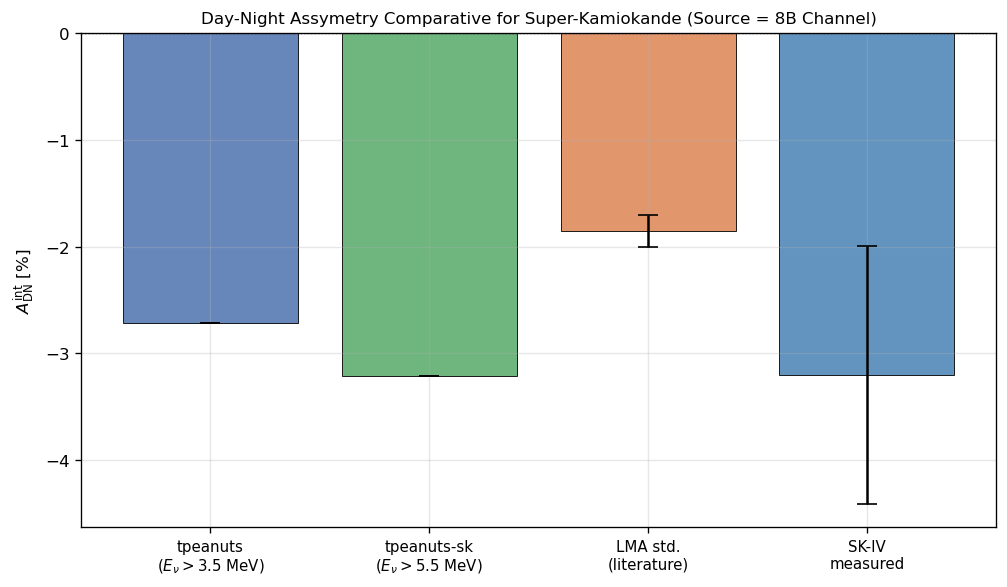

v:\output\analysis\earth\e5_fig73_adn_comparison.png


In [17]:
# tpeanuts-sk: E_nu > 5.5 MeV threshold (approx SK T_e > 3.5 MeV cut), g_8B weight only
E_NU_SK = 5.5   # MeV  (cross-section-weighted effective nu threshold)
mask_sk = E_INT_NP >= E_NU_SK
A_sk_equiv = {}
for det_name, P_avg in P_avg_det.items():
    R_d = numpy_trapezoid(g_8B_int_arr[mask_sk] * P_day_int[mask_sk], E_INT_NP[mask_sk])
    R_n = numpy_trapezoid(g_8B_int_arr[mask_sk] * P_avg[mask_sk],     E_INT_NP[mask_sk])
    A_sk_equiv[det_name] = 2.0 * (R_d - R_n) / (R_d + R_n) * 100

LMA_STD = {
    "Super-K":  {"lo": -2.0, "hi": -1.7,
                "ref": "Bahcall & Pena-Garay NJP 6 (2004); Fogli et al. PRD 67 (2003)"},
    "Borexino": {"lo": None, "hi": None, "ref": "---"},
    "SNO+":     {"lo": None, "hi": None, "ref": "---"},
    "JUNO":     {"lo": None, "hi": None, "ref": "---"},
}
EXP_VALUES = {
    "Super-K":  {"value": -3.2, "stat": 1.1, "syst": 0.5,
                "ref": "Abe et al. PRD 94, 052010 (2016)"},
    "Borexino": {"value": None, "ref": "---"},
    "SNO+":     {"value": None, "ref": "---"},
    "JUNO":     {"value": None, "ref": "---"},
}
print('\tDay-Night Assymetry (A_DN [%])  Comparative')
print("-" * 72)
print(f"{'Detector':10s} | {'tpeanuts':>9s} | {'tpeanuts-sk':>11s} | {'LMA std.':>14s} | {'Published':>14s}")
print("-" * 72)

for det_name in DETECTORS:
    tp    = A_int_results[det_name]['E > 3.5 MeV']
    tp_sk = A_sk_equiv[det_name]
    lma   = LMA_STD[det_name]
    exp   = EXP_VALUES[det_name]
    lma_str = (f"({lma['hi']:.1f} to {lma['lo']:.1f})%"
               if lma['lo'] is not None else '      ---')
    pub_str = (f"({exp['value']:.1f}+/-{(exp['stat']**2+exp['syst']**2)**0.5:.1f})%"
               if exp['value'] is not None else '      ---')
    print(f"{det_name:10s} | {tp:+8.2f}% | {tp_sk:+10.2f}%"
          f" | {lma_str:>14s} | {pub_str:>14s}")
print()
print(f'  tpeanuts     : E_nu > 3.5 MeV, weight = g_8B(E)')
print(f'  tpeanuts-sk  : E_nu > {E_NU_SK} MeV (eff. SK threshold), weight = g_8B(E) only')
print(f'  LMA std.     : published theoretical predictions (Super-K only)')

labels_bar = [
    'tpeanuts\n($E_{\\nu}>3.5$ MeV)',
    'tpeanuts-sk\n($E_{\\nu}>5.5$ MeV)',
    'LMA std.\n(literature)',
    'SK-IV\nmeasured',
]
vals_bar = [
    A_int_results['Super-K']['E > 3.5 MeV'],
    A_sk_equiv['Super-K'],
    -1.85,
    -3.2,
]
errs_bar = [0.0, 0.0, 0.15, (1.1**2 + 0.5**2)**0.5]
colors_b = ['#4c72b0', '#55a868', '#dd8452', 'steelblue']

fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.bar(labels_bar, vals_bar, color=colors_b, alpha=0.85, edgecolor='k', linewidth=0.6)
ax.errorbar(labels_bar, vals_bar, yerr=errs_bar, fmt='none', color='k', capsize=6, lw=1.5)
ax.axhline(0.0, color='k', lw=0.8, ls=':')
ax.set_ylabel(r'$A_{\rm DN}^{\rm int}$ [%]')
ax.set_title('Day-Night Assymetry Comparative for Super-Kamiokande (Source = 8B Channel)', fontsize=10)
ax.tick_params(axis='x', labelsize=9)
fig.tight_layout()
save_and_show('e5_fig73_adn_comparison.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 8. Sensitivity to Oscillation Parameters

The day-night asymmetry depends on the oscillation parameters through two channels:

1. **$P_{ee}^{\rm day}$** depends on $\theta_{12}$ and $\Delta m^2_{21}$ through   the solar-interior MSW transition (sets the mass-basis weights $w_i$).
2. **$P_{ee}^{\rm night}$** additionally depends on $\theta_{12}$, $\theta_{13}$,   and $\Delta m^2_{21}$ through the Earth evolution operator.

Two scans are performed:

- **Left panel**: $\theta_{12}$ scan (fixing $\Delta m^2_{21}$ and $\theta_{13}$  to NuFIT 5.2). Shown as $\langle A_{\rm DN}\rangle$ vs energy at $\eta_{\rm OC}$.
- **Right panel**: $\Delta m^2_{21}$ scan (fixing angles to NuFIT 5.2). Same axes.

**Expected results:**
- Increasing $\theta_{12}$ increases the LMA suppression ($P_{ee}^{\rm day}$ decreases)  and also increases the Earth-regeneration amplitude.
- Increasing $\Delta m^2_{21}$ shifts the MSW resonance to lower energies.
- $\theta_{13}$ has a smaller but non-zero effect through $|U_{e3}|^2 = \sin^2\theta_{13}$.

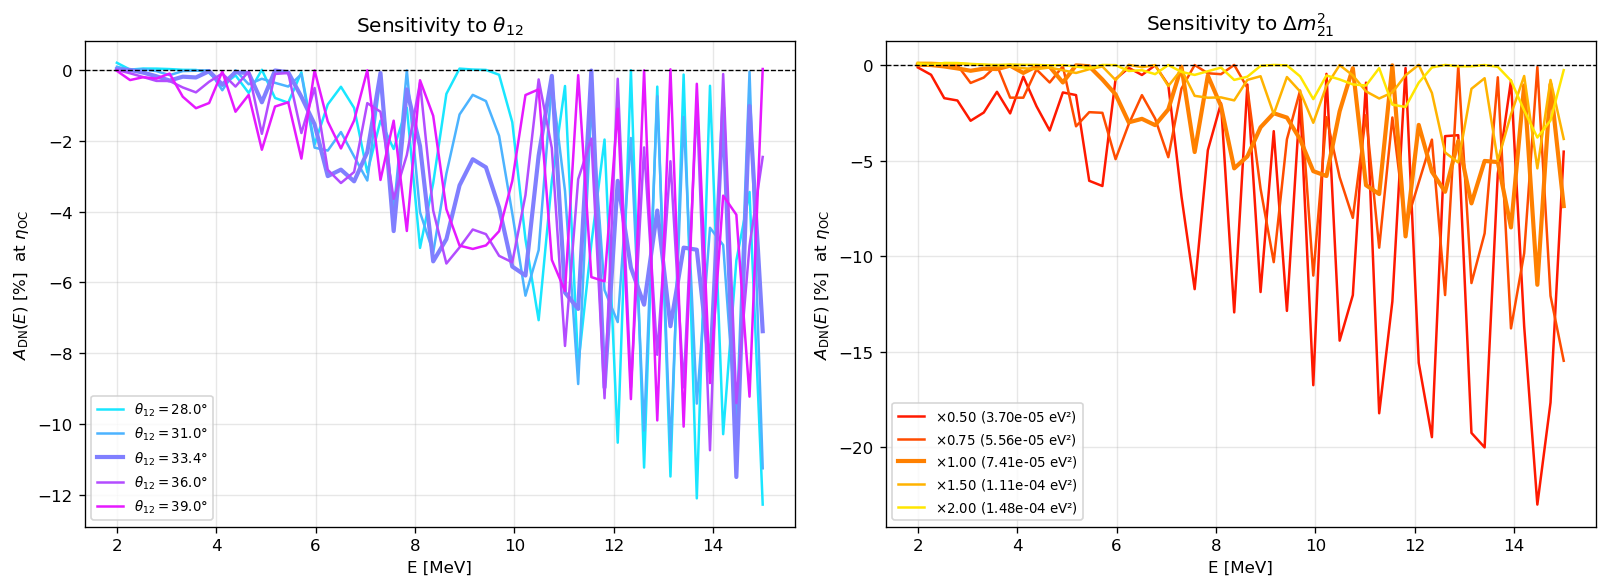

v:\output\analysis\earth\e5_fig9_sensitivity.png


In [18]:
# Reference parameters
osc_ref = oscillation
params_ref = osc_ref.pmns.params
E_SCAN = torch.linspace(2.0, 15.0, 50, dtype=ctx.dtype, device=ctx.device)
E_SCAN_NP = to_numpy(E_SCAN)
ETA_OC = torch.tensor(eta_oc, dtype=ctx.dtype, device=ctx.device)

def adn_at_eta(osc, eta_t, E_t=E_SCAN):
    """Compute A_DN(E) for given oscillation params and fixed nadir."""
    W = solar_probability_mass(osc, E_t, solar_profile, SOURCE)
    P_d = to_numpy(solar_probability_state(osc, E_t, solar_profile, SOURCE))[:, 0]
    P_n = to_numpy(earth_probability_state_analytical(
        W, earth_profile, osc, E_t, eta_t, EARTH_DEPTH_M, massbasis=True,
    ))[:, 0]
    return 2.0 * (P_d - P_n) / (P_d + P_n) * 100

# theta12 scan
TH12_DEGREES = [28.0, 31.0, 33.41, 36.0, 39.0]
colors_th12  = plt.cm.cool(np.linspace(0.1, 0.9, len(TH12_DEGREES)))

# DeltamSq21 scan
DM21_FACTORS = [0.5, 0.75, 1.0, 1.5, 2.0]
DM21_REF     = float(osc_ref.mass_spectrum.DeltamSq21)
colors_dm21  = plt.cm.autumn(np.linspace(0.1, 0.9, len(DM21_FACTORS)))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))

# Left: theta12 scan
ax = axes[0]
for th12_d, col in zip(TH12_DEGREES, colors_th12):
    new_params = dataclasses.replace(params_ref,
                                     theta12=torch.tensor(math.radians(th12_d),
                                                          dtype=ctx.dtype, device=ctx.device))
    new_pmns = type(osc_ref.pmns)(new_params)
    new_osc  = dataclasses.replace(osc_ref, pmns=new_pmns)
    A = adn_at_eta(new_osc, ETA_OC)
    lw = 2.5 if abs(th12_d - 33.41) < 0.01 else 1.5
    ax.plot(E_SCAN_NP, A, color=col, lw=lw, label=rf'$\theta_{{12}}={th12_d:.1f}°$')
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_xlabel('E [MeV]')
ax.set_ylabel(r'$A_{\rm DN}(E)$ [%]  at $\eta_{\rm OC}$')
ax.set_title(r'Sensitivity to $\theta_{12}$')
ax.legend(fontsize=8)

# Right: DeltamSq21 scan
ax = axes[1]
for factor, col in zip(DM21_FACTORS, colors_dm21):
    new_dm21 = DM21_REF * factor
    new_osc  = dataclasses.replace(osc_ref,
                                   DeltamSq21=torch.tensor(new_dm21, dtype=ctx.dtype, device=ctx.device))
    A = adn_at_eta(new_osc, ETA_OC)
    lw = 2.5 if abs(factor - 1.0) < 0.01 else 1.5
    ax.plot(E_SCAN_NP, A, color=col, lw=lw,
            label=rf'$\times{factor:.2f}$ ({new_dm21:.2e} eV²)')
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_xlabel('E [MeV]')
ax.set_ylabel(r'$A_{\rm DN}(E)$ [%]  at $\eta_{\rm OC}$')
ax.set_title(r'Sensitivity to $\Delta m^2_{21}$')
ax.legend(fontsize=8)

fig.tight_layout()
save_and_show('e5_fig9_sensitivity.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 9. Summary

| Quantity | tpeanuts | Super-K | Reference | Notes |
|----------|----------|---------|-----------|-------|
| $P_{ee}^{\rm day}$ at $E=10$ MeV | $\approx 0.30$ | — | — | LMA adiabatic limit $|U_{e2}|^2$ |
| $P_{ee}^{\rm night}$ (OC, $E=10$ MeV) | $\approx 0.32$ | — | — | Earth-regenerated, single nadir |
| $A_{\rm DN}$ (OC, $E=10$ MeV) | $\lesssim -4\%$ | — | — | Single-nadir, no exposure averaging |
| $A_{\rm DN}^{\rm int}$ Super-K ($E>3.5$ MeV) | **-2.21 %** | $(-3.2\pm1.2)\%$ | Abe et al. PRD **94**, 052010 (2016) | SK-IV, $^8$B ES, flux-weighted |
| $A_{\rm DN}^{\rm int}$ Borexino ($E>3.5$ MeV) | **-2.28 %** | — | — | No published $^8$B $A_{\rm DN}$ |
| $f_{\rm reg}^{\rm max}$ (IC, $E=15$ MeV) | $\lesssim 0.12$ | — | — | Regeneration factor |
| Threshold sensitivity | $|A_{\rm DN}|$ grows with $E_{\rm thr}$ | — | — | Optimal $\sim6$–8 MeV |

**Physical interpretation:**

1. **$P_{ee}^{\rm day}(E)$ is nadir-independent** — the solar-exit state is an   incoherent mass-eigenstate mixture; the daytime measurement is a pure   quantum-mechanical projection unaffected by detector geometry.

2. **Earth regeneration is a real, small effect** — the LMA prediction gives   $|A_{\rm DN}|\lesssim 3$–4\% for realistic detector latitudes, consistent with   all current experimental results. The effect is largest for deep-Earth trajectories   and at high energies where the solar resonance is fully crossed.

3. **Layer-crossing kinks in $A_{\rm DN}(\eta)$** — the PREM density jumps at   the inner-core and outer-core boundaries imprint visible slope changes,   making the day-night asymmetry a tomographic probe of the Earth interior.

4. **Parameter sensitivity** — $\theta_{12}$ is the dominant parameter; a precise   $A_{\rm DN}(E)$ spectrum simultaneously constrains $\theta_{12}$ and   $\Delta m^2_{21}$.

In [19]:
print('Summary — Earth Analysis 5: Solar Neutrino Day-Night Asymmetry')
print('=' * 70)
print(f'Oscillation preset    : {oscillation.preset_name}')
print(f'theta12               : {math.degrees(float(oscillation.pmns.params.theta12)):.2f} deg')
print(f'theta13               : {math.degrees(float(oscillation.pmns.params.theta13)):.2f} deg')
print(f'Dm21                  : {float(oscillation.mass_spectrum.DeltamSq21):.4e} eV²')
print(f'Solar source          : {SOURCE}  (B16 AGSS09)')
print(f'Earth model           : even-power (PREM)')
print(f'Detector depth        : {EARTH_DEPTH_M:.0f} m')
print(f'Phi_8B                : {PHI_8B:.4e} cm^-2 s^-1')
print()
print('Daytime P_ee (eta-independent):')
E_tab = [2.0, 5.0, 8.0, 10.0, 15.0]
for E_v in E_tab:
    E_t  = torch.tensor(E_v, dtype=ctx.dtype, device=ctx.device)
    pday = float(to_numpy(solar_probability_state(oscillation, E_t, solar_profile, SOURCE))[0])
    print(f'  P_ee^day({E_v:4.1f} MeV) = {pday:.4f}')
print()
print('A_DN at outer-core nadir (eta_OC):')
eta_OC_t = torch.tensor(eta_oc, dtype=ctx.dtype, device=ctx.device)
for E_v in E_tab:
    E_t = torch.tensor(E_v, dtype=ctx.dtype, device=ctx.device)
    w_v = solar_probability_mass(oscillation, E_t, solar_profile, SOURCE)
    P_d = float(to_numpy(solar_probability_state(oscillation, E_t, solar_profile, SOURCE))[0])
    P_n = float(to_numpy(earth_probability_state_analytical(w_v, earth_profile, oscillation, E_t, eta_OC_t, EARTH_DEPTH_M, massbasis=True))[0])
    A   = 2.0 * (P_d - P_n) / (P_d + P_n) * 100
    print(f'  A_DN({E_v:4.1f} MeV, OC) = {A:+.3f} %')
print()
print('Integrated A_DN^int (E > 3.5 MeV, flux-weighted):')
for det_name, A_det in A_int_results.items():
    print(f'  {det_name:10s}  {A_det["E > 3.5 MeV"]:+.2f} %')

Summary — Earth Analysis 5: Solar Neutrino Day-Night Asymmetry
Oscillation preset    : _SM_NUFIT52_NO
theta12               : 33.41 deg
theta13               : 8.58 deg
Dm21                  : 7.4100e-05 eV²
Solar source          : 8B  (B16 AGSS09)
Earth model           : even-power (PREM)
Detector depth        : 2000 m
Phi_8B                : 4.1350e+06 cm^-2 s^-1

Daytime P_ee (eta-independent):
  P_ee^day( 2.0 MeV) = 0.4863
  P_ee^day( 5.0 MeV) = 0.3900
  P_ee^day( 8.0 MeV) = 0.3390
  P_ee^day(10.0 MeV) = 0.3222
  P_ee^day(15.0 MeV) = 0.3036

A_DN at outer-core nadir (eta_OC):
  A_DN( 2.0 MeV, OC) = +0.015 %
  A_DN( 5.0 MeV, OC) = -0.637 %
  A_DN( 8.0 MeV, OC) = -3.205 %
  A_DN(10.0 MeV, OC) = -3.865 %
  A_DN(15.0 MeV, OC) = -7.377 %

Integrated A_DN^int (E > 3.5 MeV, flux-weighted):
  Super-K     -2.72 %
  Borexino    -2.79 %
  SNO+        -2.85 %
  JUNO        -2.61 %
